In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

# Heatmaps of gene expression across cancer lineages

In [2]:
# Reducing the Models data
Models = pd.read_csv('Model.csv', low_memory=False)
#list(Models)

Models_Meta_data = ['PatientID','CellLineName','StrippedCellLineName','DepmapModelType','OncotreeCode',
 'PatientSubtypeFeatures','RRID','PrimaryOrMetastasis','SampleCollectionSite','SourceType','SourceDetail',
 'CatalogNumber','ModelType','TissueOrigin','ModelDerivationMaterial','ModelTreatment','PatientTreatmentStatus',
 'PatientTreatmentType','PatientTreatmentDetails','Stage','StagingSystem','PatientTumorGrade',
 'PatientTreatmentResponse','GrowthPattern','OnboardedMedia','FormulationID','SerumFreeMedia','PlateCoating',
 'EngineeredModel','EngineeredModelDetails','CulturedResistanceDrug','PublicComments','CCLEName','HCMIID',
 'PediatricModelType','ModelAvailableInDbgap','ModelSubtypeFeatures','WTSIMasterCellID','SangerModelID',
 'COSMICID','ModelIDAlias']
meta_model_cols = [c for c in Models_Meta_data if c in Models.columns]
model_reduced_cols = gene_cols = [c for c in Models.columns if c not in meta_model_cols]
Models_reduced = Models[model_reduced_cols]
#Models_reduced.drop_duplicates(keep='first', inplace=True)
Models_reduced

,ModelID,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,Age,AgeCategory,Sex,PatientRace
0,ACH-000001,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
1,ACH-000002,Myeloid,Acute Myeloid Leukemia,AML with Myelodysplasia-Related Changes,36.0,Adult,Female,caucasian
2,ACH-000003,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,72.0,Adult,Male,caucasian
3,ACH-000004,Myeloid,Acute Myeloid Leukemia,"AML, NOS",30.0,Adult,Male,caucasian
4,ACH-000005,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,30.0,Adult,Male,caucasian
...,...,...,...,...,...,...,...,...
2127,ACH-003473,Soft Tissue,Rhabdomyosarcoma,Embryonal Rhabdomyosarcoma,1.0,Pediatric,Female,caucasian
2128,ACH-003474,Head and Neck,Head and Neck Squamous Cell Carcinoma,Head and Neck Squamous Cell Carcinoma,77.0,Adult,Male,caucasian
2129,ACH-003475,Head and Neck,Head and Neck Squamous Cell Carcinoma,Head and Neck Squamous Cell Carcinoma,76.0,Adult,Female,caucasian
2130,ACH-003476,Esophagus/Stomach,Esophageal Squamous Cell Carcinoma,Esophageal Squamous Cell Carcinoma,76.0,Adult,Female,caucasian


In [3]:
# Reducing the Profiles data
Profiles = pd.read_csv('OmicsProfiles.csv', low_memory=False)
#list(Profiles)

Profiles_Meta_data= ['IsDefaultEntryForModel','StrippedCellLineName','DepMapCode','ModelConditionID',
 'IsDefaultEntryForMC','SourceModelCondition','CellFormat','GrowthMedia','GrowthPattern','ProfileID',
 'SequencingPlatform','DataType','Stranded','SharedToDbGaP','SequencingDate','ModelID'] #'SequencingID' 'ModelID'
profiles_model_cols = [c for c in Profiles_Meta_data if c in Profiles.columns]
profiles_reduced_cols = gene_cols = [c for c in Profiles.columns if c not in profiles_model_cols]
Profiles_reduced = Profiles[profiles_reduced_cols]
#Profiles_reduced_duplicates = Profiles_reduced.drop_duplicates(keep='first') #, inplace=True
#Profiles_reduced

# index Expressions_reduced by 'SequencingID'
Profiles_reduced_Index = Profiles_reduced.set_index("SequencingID")
Profiles_reduced_Index

,Lineage
SequencingID,
CDS-VqxBGH,Ovary/Fallopian Tube
CDS-1pLoxn,Ovary/Fallopian Tube
CDS-C3gZIu,Ovary/Fallopian Tube
CDS-qqF7T8,Ovary/Fallopian Tube
CDS-FvwPIb,Ovary/Fallopian Tube
...,...
CDS-k5gIOX,Pancreas
CDS-KoBwnR,Bone
CDS-5xnEtM,Bone


In [4]:
# Reducing the Expression data
Expression = pd.read_csv('OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv', low_memory=False)
#list(Expression)

Expressions_Meta_data = ['Unnamed: 0','IsDefaultEntryForModel','ModelConditionID','ModelID',
                         'IsDefaultEntryForMC']#'SequencingID' 'ModelID'
expressions_model_cols = [c for c in Expressions_Meta_data if c in Expression.columns]
expressions_reduced_cols = gene_cols = [c for c in Expression.columns if c not in expressions_model_cols]
Expressions_reduced = Expression[expressions_reduced_cols]
#Expressions_reduced.drop_duplicates(keep='first', inplace=True)
#Expressions_reduced

# index Expressions_reduced by 'SequencingID'
Expressions_reduced_Index = Expressions_reduced.set_index("SequencingID")
Expressions_reduced_Index

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
SequencingID,,,,,,,,,,,,,,,,,,,,,
CDS-010xbm,4.956577,0.000000,7.577648,3.179411,4.765742,0.037483,1.510547,3.103039,6.697482,4.852304,...,0.0,0.000000,0.414727,0.077634,1.113094,0.411901,0.0,5.134808,1.214541,4.315653
CDS-02TzJp,4.954992,0.617243,7.334747,2.783576,3.736280,0.000000,0.149060,3.855960,4.377061,3.466249,...,0.0,0.000000,0.029840,0.000000,1.262156,1.026871,0.0,5.951231,0.007227,4.251060
CDS-0693hw,3.421952,0.000000,7.546069,2.615880,4.476233,0.064571,1.397491,6.833915,3.980336,3.437154,...,0.0,0.000000,0.127768,0.105594,0.413829,0.540575,0.0,4.205971,0.030894,2.783448
CDS-07Plat,5.196729,0.000000,6.362268,2.144996,3.087183,0.036001,5.118850,7.013295,6.177005,3.509987,...,0.0,0.000000,0.075396,0.932918,0.000000,0.511978,0.0,4.510747,3.223597,5.106595
CDS-08FOcu,4.651643,0.000000,5.946408,2.454515,1.852111,0.000000,7.680796,6.156866,5.042574,3.258451,...,0.0,0.000000,0.012012,0.000000,1.006470,0.729221,0.0,4.922916,0.150926,4.661556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDS-zsS3zE,3.770702,0.000000,7.380245,1.803405,4.191989,0.013924,4.023557,6.989366,4.815309,4.503457,...,0.0,0.000000,0.032260,0.890296,0.185355,0.211497,0.0,5.602071,0.000000,7.062305
CDS-zsp0NA,4.886794,0.000000,7.245942,2.187771,3.611621,0.020211,3.658680,6.957810,5.617589,3.420170,...,0.0,0.000000,1.727733,0.311457,0.179430,0.468641,0.0,5.290513,0.030359,5.632411
CDS-zvrgDc,5.721963,0.000000,8.299822,3.008067,4.362596,0.000000,4.620053,7.230376,4.995132,3.555571,...,0.0,0.000000,0.002292,2.102581,0.005078,0.382775,0.0,4.417502,0.008285,5.242202


In [5]:
# recreate the Model_Expression_reduced like we did in R
Profiles_Expression_reduced = pd.merge(Profiles_reduced_Index, Expressions_reduced_Index, on="SequencingID")
Profiles_Expression_reduced

,Lineage,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
SequencingID,,,,,,,,,,,,,,,,,,,,,
CDS-VqxBGH,Ovary/Fallopian Tube,5.490942,0.00000,7.558490,2.306714,4.423215,0.046938,1.042448,5.904893,5.125176,...,0.000000,0.063369,0.029583,1.521764,1.713788,0.798202,0.0,6.552359,0.000000,5.515829
CDS-qqF7T8,Ovary/Fallopian Tube,5.097872,0.06319,7.709780,1.959236,3.633408,0.024325,2.118420,5.478529,4.358579,...,0.000000,0.029822,0.024877,0.267380,1.348232,0.579396,0.0,6.040605,0.000000,4.932930
CDS-kpzIIP,Ovary/Fallopian Tube,4.262486,0.00000,6.477196,2.490498,3.639012,0.085499,4.061379,4.328980,4.288233,...,0.000000,0.101602,0.016118,1.491207,0.667077,0.503766,0.0,5.349256,0.000000,4.013605
CDS-Dc4piF,Ovary/Fallopian Tube,5.250852,0.00000,6.504501,2.288766,3.923748,0.025441,0.883857,6.570823,4.980185,...,0.000000,0.034469,0.245185,0.278430,0.429859,1.482270,0.0,7.178595,0.000000,5.413540
CDS-PP0aCP,Ovary/Fallopian Tube,5.963250,0.00000,6.409170,2.951543,4.515763,0.020494,3.699918,5.588877,3.656428,...,0.029468,0.000000,0.500686,1.434940,0.244384,1.078924,0.0,5.251227,2.323428,4.913272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDS-jsRCMr,Hair,4.737503,0.00000,7.077254,2.583459,4.812026,0.153782,5.992487,6.809067,4.370548,...,0.000000,0.000000,0.020134,0.458883,0.090925,0.789112,0.0,5.322220,0.916229,4.202488
CDS-lp24FU,Hair,4.940200,0.00000,7.389851,2.878559,4.892372,0.150839,4.104966,6.646298,5.195741,...,0.000000,0.000000,0.036527,0.383698,0.188350,1.255990,0.0,5.702453,4.077294,4.920903
CDS-k5gIOX,Pancreas,4.854075,0.00000,7.491733,2.757572,4.730971,0.000000,4.712585,6.666487,4.396379,...,0.000000,0.000000,0.000000,0.171379,0.000000,0.632722,0.0,5.696475,2.655052,4.967081


In [6]:
# make a new dataframe that is grouped by 'Lineage', and I will take the median value
# I took the median value in hopes to not distort any trends that should exist and remain
PE_reduced_groupby_Lineage = Profiles_Expression_reduced.groupby(by="Lineage", dropna=True).median()
PE_reduced_groupby_Lineage

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
Lineage,,,,,,,,,,,,,,,,,,,,,
Adrenal Gland,5.083899,0.142063,7.096593,2.553131,5.025922,0.005376,0.113983,2.642539,4.305339,4.726559,...,0.0,0.0,0.309819,0.094626,0.544868,1.683145,0.0,4.975019,0.093954,4.864537
Ampulla of Vater,4.771627,0.000000,6.958599,2.713722,4.092926,0.051297,2.638447,6.390408,5.432649,3.894333,...,0.0,0.0,0.003738,1.020193,0.005078,0.440394,0.0,5.161904,0.008285,5.151323
Biliary Tract,4.927954,0.000000,6.944848,2.504190,3.542903,0.031488,5.047847,6.113367,5.378403,3.634396,...,0.0,0.0,0.104572,0.991808,0.066474,0.491540,0.0,4.812407,1.168149,5.087336
Bladder/Urinary Tract,4.659077,0.000000,7.032316,2.537269,4.107742,0.074681,2.476338,6.052444,4.867139,3.877073,...,0.0,0.0,0.405183,0.972799,0.012140,0.628126,0.0,5.707711,0.035650,4.633541
Bone,4.623732,0.000000,6.643289,2.622912,4.291412,0.032226,2.486192,5.400340,4.253566,4.390179,...,0.0,0.0,0.013501,0.297445,0.730110,0.726421,0.0,5.525323,0.017769,4.769015
Bowel,4.690976,0.021177,6.780074,2.729533,3.696417,0.024610,0.148095,6.108635,5.519885,3.913943,...,0.0,0.0,0.000000,1.536506,0.034858,0.757726,0.0,5.581336,0.070297,4.472611
Breast,3.752716,0.000000,6.794234,2.979071,3.981159,0.057360,0.272187,5.709178,5.077833,4.097560,...,0.0,0.0,0.023059,1.246353,0.042116,0.814806,0.0,5.704593,0.066705,4.694028
CNS/Brain,4.456035,0.000000,6.753231,2.433684,3.953568,0.039396,2.836240,6.395482,4.338332,4.028202,...,0.0,0.0,0.009718,0.238017,0.066104,0.932624,0.0,5.649319,0.000018,4.875170
Cervix,4.516817,0.000000,7.205832,2.322337,3.584931,0.022978,1.349909,5.993335,4.923624,3.733854,...,0.0,0.0,0.305892,0.979381,0.031435,0.496646,0.0,5.493828,2.521676,4.792014


In [7]:
# make a dataframe that only take the top N genes that have the highest variance
PE_gene_variances = PE_reduced_groupby_Lineage.var(axis=0, ddof=1)
PE_gene_variances_sorted = PE_gene_variances.sort_values(ascending=False)
PE_top_genes = PE_gene_variances_sorted.head(50)
#print(PE_top_genes)

PE_top_50_var = PE_reduced_groupby_Lineage[PE_top_genes.index]
PE_top_50_var

,COL1A2 (1278),SPARC (6678),KRT19 (3880),KRT8 (3856),EPCAM (4072),THY1 (7070),C19orf33 (64073),SPINT2 (10653),COL1A1 (1277),KRT7 (3855),...,DCN (1634),COL6A2 (1292),ANXA3 (306),S100P (6286),AGR2 (10551),MGST1 (4257),ESRP1 (54845),RPS4Y1 (6192),THBS1 (7057),CCL2 (6347)
Lineage,,,,,,,,,,,,,,,,,,,,,
Adrenal Gland,0.131706,5.626824,0.664768,1.433937,2.680412,2.842519,0.516336,5.368257,1.808675,1.082774,...,0.699933,4.249817,0.161026,0.869533,0.332267,4.422680,0.347076,0.087429,1.321285,0.288552
Ampulla of Vater,0.661799,2.221809,10.710806,11.525139,9.594619,0.073033,8.585954,8.966090,3.532018,10.021105,...,0.367496,0.363173,8.393807,8.567766,7.135720,8.297370,5.940385,0.518968,7.158408,1.960801
Biliary Tract,0.086119,1.732681,10.128668,10.836637,8.146142,0.133645,8.546763,8.739789,2.533767,9.484326,...,0.192339,2.407164,7.145059,5.032062,6.510802,9.398287,6.071046,0.000000,5.879726,1.827356
Bladder/Urinary Tract,1.070917,4.570533,9.670065,10.287870,7.119254,0.450033,7.700291,8.548212,2.832629,10.098344,...,0.366842,1.497522,6.951042,5.395868,3.505610,8.572171,5.900062,0.840672,6.681336,0.389507
Bone,7.473389,8.772608,0.593007,2.644295,0.721158,6.473933,0.066628,1.373481,7.771648,1.268147,...,4.875638,5.695699,0.746190,0.256392,0.148167,6.134714,0.534651,0.557870,5.716088,2.116924
Bowel,0.394996,1.305988,9.291509,11.248847,9.763473,0.169094,7.522582,8.661853,1.476221,3.479606,...,0.267242,0.292180,6.834016,8.214543,8.934646,7.965063,6.285034,0.481768,4.096709,0.228400
Breast,0.565488,1.974911,10.306198,10.185594,7.861186,0.216781,5.898017,9.123118,3.607579,9.227671,...,0.185851,1.600750,4.506780,5.505319,6.214208,8.601489,6.303741,0.409384,5.848828,0.778869
CNS/Brain,7.726078,10.791809,1.458284,5.009307,0.854486,8.087099,0.579805,1.515435,6.949796,3.154440,...,1.654691,7.132125,0.856551,0.624139,0.455722,7.815023,0.257515,3.300388,8.075685,5.824517
Cervix,0.095630,1.209547,8.213952,10.074866,7.181623,0.120304,8.508551,8.559183,2.995748,10.044388,...,0.402877,0.706186,7.314554,6.118263,0.645528,8.718468,5.827975,0.000000,6.127987,0.313174


<Axes: ylabel='Lineage'>

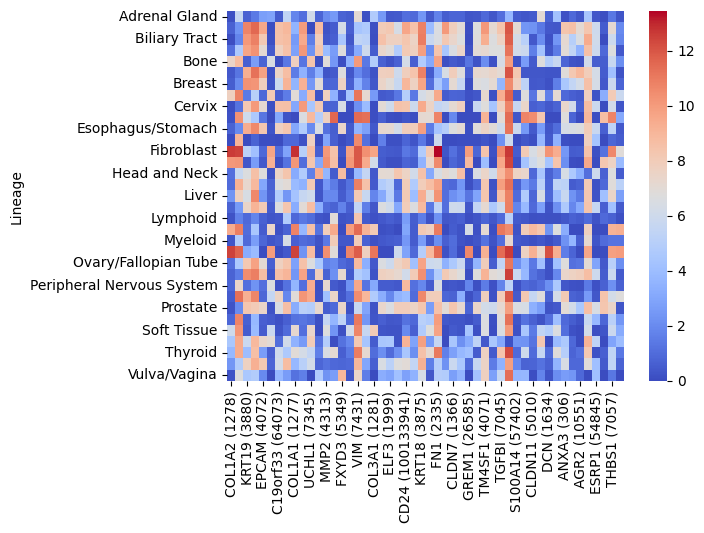

In [8]:
sns.heatmap(PE_top_50_var, cmap="coolwarm")

In [9]:
# remove lineages that only have >=10 amount of observations
lineages = Profiles_Expression_reduced["Lineage"]
class_counts = Profiles_Expression_reduced[lineages.name].value_counts()
classes_to_keep = class_counts[class_counts >= 10].index
PE_lineages_reduced = Profiles_Expression_reduced[Profiles_Expression_reduced[lineages.name].isin(classes_to_keep)]

#PE_lineages_reduced["Lineage"].value_counts()
PE_lineages_reduced

,Lineage,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
SequencingID,,,,,,,,,,,,,,,,,,,,,
CDS-VqxBGH,Ovary/Fallopian Tube,5.490942,0.00000,7.558490,2.306714,4.423215,0.046938,1.042448,5.904893,5.125176,...,0.000000,0.063369,0.029583,1.521764,1.713788,0.798202,0.0,6.552359,0.000000,5.515829
CDS-qqF7T8,Ovary/Fallopian Tube,5.097872,0.06319,7.709780,1.959236,3.633408,0.024325,2.118420,5.478529,4.358579,...,0.000000,0.029822,0.024877,0.267380,1.348232,0.579396,0.0,6.040605,0.000000,4.932930
CDS-kpzIIP,Ovary/Fallopian Tube,4.262486,0.00000,6.477196,2.490498,3.639012,0.085499,4.061379,4.328980,4.288233,...,0.000000,0.101602,0.016118,1.491207,0.667077,0.503766,0.0,5.349256,0.000000,4.013605
CDS-Dc4piF,Ovary/Fallopian Tube,5.250852,0.00000,6.504501,2.288766,3.923748,0.025441,0.883857,6.570823,4.980185,...,0.000000,0.034469,0.245185,0.278430,0.429859,1.482270,0.0,7.178595,0.000000,5.413540
CDS-PP0aCP,Ovary/Fallopian Tube,5.963250,0.00000,6.409170,2.951543,4.515763,0.020494,3.699918,5.588877,3.656428,...,0.029468,0.000000,0.500686,1.434940,0.244384,1.078924,0.0,5.251227,2.323428,4.913272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDS-xszVVB,Liver,4.149186,0.00000,8.066105,2.823499,5.061612,0.021954,3.467214,6.190050,4.885613,...,0.000000,0.000000,0.057646,0.363143,0.214947,0.656728,0.0,5.298468,0.002847,4.164078
CDS-YgH5wL,Lung,3.954382,0.00000,6.916286,3.020931,3.598175,0.113647,7.875301,6.533104,4.832860,...,0.000000,0.000000,0.000000,0.506279,0.000000,1.233084,0.0,5.484709,0.031539,3.979440
CDS-k5gIOX,Pancreas,4.854075,0.00000,7.491733,2.757572,4.730971,0.000000,4.712585,6.666487,4.396379,...,0.000000,0.000000,0.000000,0.171379,0.000000,0.632722,0.0,5.696475,2.655052,4.967081


In [10]:
# make new dataframe that is grouped by 'Lineage' using the reduced lineages
# since different sequencing were performed, genes have multiple different values within the same 'Lineage'
# take the median value (can maybe switch to mean, because 0 actually means something)
PE_grouped_lineages_reduced = PE_lineages_reduced.groupby(by="Lineage", dropna=True).median()
PE_grouped_lineages_reduced

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
Lineage,,,,,,,,,,,,,,,,,,,,,
Biliary Tract,4.927954,0.000000,6.944848,2.504190,3.542903,0.031488,5.047847,6.113367,5.378403,3.634396,...,0.0,0.0,0.104572,0.991808,0.066474,0.491540,0.0,4.812407,1.168149,5.087336
Bladder/Urinary Tract,4.659077,0.000000,7.032316,2.537269,4.107742,0.074681,2.476338,6.052444,4.867139,3.877073,...,0.0,0.0,0.405183,0.972799,0.012140,0.628126,0.0,5.707711,0.035650,4.633541
Bone,4.623732,0.000000,6.643289,2.622912,4.291412,0.032226,2.486192,5.400340,4.253566,4.390179,...,0.0,0.0,0.013501,0.297445,0.730110,0.726421,0.0,5.525323,0.017769,4.769015
Bowel,4.690976,0.021177,6.780074,2.729533,3.696417,0.024610,0.148095,6.108635,5.519885,3.913943,...,0.0,0.0,0.000000,1.536506,0.034858,0.757726,0.0,5.581336,0.070297,4.472611
Breast,3.752716,0.000000,6.794234,2.979071,3.981159,0.057360,0.272187,5.709178,5.077833,4.097560,...,0.0,0.0,0.023059,1.246353,0.042116,0.814806,0.0,5.704593,0.066705,4.694028
CNS/Brain,4.456035,0.000000,6.753231,2.433684,3.953568,0.039396,2.836240,6.395482,4.338332,4.028202,...,0.0,0.0,0.009718,0.238017,0.066104,0.932624,0.0,5.649319,0.000018,4.875170
Cervix,4.516817,0.000000,7.205832,2.322337,3.584931,0.022978,1.349909,5.993335,4.923624,3.733854,...,0.0,0.0,0.305892,0.979381,0.031435,0.496646,0.0,5.493828,2.521676,4.792014
Esophagus/Stomach,4.403032,0.000000,6.868458,2.561295,3.835405,0.029803,1.273528,5.849975,5.587014,3.935869,...,0.0,0.0,0.038350,0.910744,0.032177,0.675246,0.0,5.791354,0.565310,4.249682
Eye,4.769170,0.000000,6.514472,2.578705,3.365117,0.000000,0.719294,5.914075,4.296595,3.981748,...,0.0,0.0,0.010150,0.365146,0.405737,0.442808,0.0,4.932503,0.000000,5.280004


In [11]:
# make a dataframe that only take the top N genes that have the highest variance from the reduced Lineage df
PE_lineages_reduced_gene_variances = PE_grouped_lineages_reduced.var(axis=0, ddof=1)
PE_lineages_reduced_gene_variances_sorted = PE_lineages_reduced_gene_variances.sort_values(ascending=False)
PE_lineages_reduced_top_genes = PE_lineages_reduced_gene_variances_sorted.head(50)
#print(PE_lineages_reduced_top_genes)

PE_lineages_reduced_top_50_var = PE_grouped_lineages_reduced[PE_lineages_reduced_top_genes.index]
PE_lineages_reduced_top_50_var

,SPARC (6678),KRT19 (3880),EPCAM (4072),KRT8 (3856),C19orf33 (64073),TACSTD2 (4070),KRT7 (3855),SPINT2 (10653),FXYD3 (5349),VIM (7431),...,SRGN (5552),SPINT1 (6692),ST14 (6768),EFEMP1 (2202),GJA1 (2697),TINAGL1 (64129),S100A16 (140576),PRSS8 (5652),COL3A1 (1281),MGST1 (4257)
Lineage,,,,,,,,,,,,,,,,,,,,,
Biliary Tract,1.732681,10.128668,8.146142,10.836637,8.546763,7.968773,9.484326,8.739789,4.419105,5.361191,...,0.628665,6.900447,5.522485,5.042854,2.048590,6.168808,8.251167,5.464765,0.057158,9.398287
Bladder/Urinary Tract,4.570533,9.670065,7.119254,10.287870,7.700291,8.352029,10.098344,8.548212,6.766111,3.158693,...,2.574184,6.816283,5.720806,5.873263,4.225857,7.613451,8.106373,4.172691,0.490554,8.572171
Bone,8.772608,0.593007,0.721158,2.644295,0.066628,0.129807,1.268147,1.373481,0.086119,10.059088,...,2.447092,1.275734,0.067920,2.599880,6.746299,0.270646,1.871650,0.087494,4.856811,6.134714
Bowel,1.305988,9.291509,9.763473,11.248847,7.522582,3.511038,3.479606,8.661853,6.752347,1.940125,...,0.444658,6.849849,6.777341,0.317754,0.333101,5.804658,7.931086,6.467506,0.219331,7.965063
Breast,1.974911,10.306198,7.861186,10.185594,5.898017,6.935024,9.227671,9.123118,7.646400,3.403734,...,0.804785,6.728370,5.543493,5.279092,0.461992,3.589344,8.123175,6.007619,0.324386,8.601489
CNS/Brain,10.791809,1.458284,0.854486,5.009307,0.579805,0.262194,3.154440,1.515435,0.403133,11.176285,...,3.468426,0.958494,0.179872,6.727110,6.858118,0.632121,7.612422,0.191174,2.563591,7.815023
Cervix,1.209547,8.213952,7.181623,10.074866,8.508551,8.168779,10.044388,8.559183,6.356273,2.163366,...,0.688924,6.129973,4.428522,7.429612,0.817923,5.918837,8.325468,3.214939,0.091232,8.718468
Esophagus/Stomach,1.975116,9.343247,8.314053,10.572525,7.766059,6.411955,4.774429,8.334852,7.401630,3.568491,...,0.562062,6.171765,5.776356,2.488060,2.576770,6.137214,8.023302,4.604152,0.367731,8.026899
Eye,9.105952,0.000000,0.065068,0.682643,0.000000,0.006481,0.178559,0.842852,0.000000,10.563765,...,0.599918,0.377241,0.000000,0.366623,3.723323,0.088101,5.264963,0.022207,0.008347,7.774616


# Figure 1

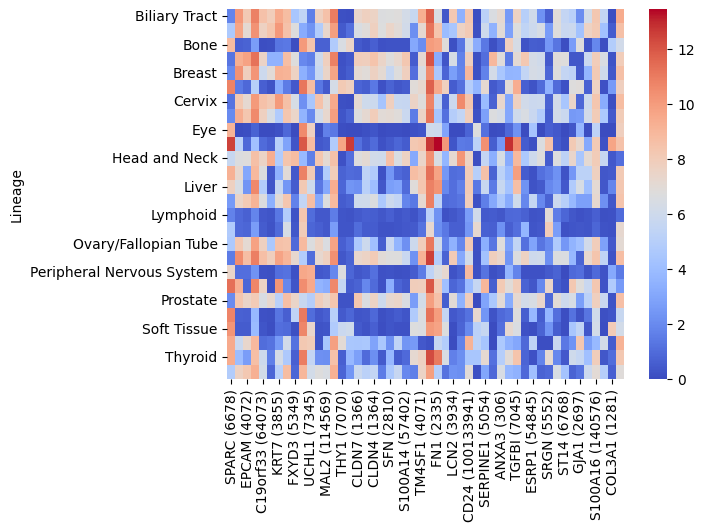

In [12]:
# heatmap of the top 50 varianced genes using the reduced lineages
sns.heatmap(PE_lineages_reduced_top_50_var, cmap="coolwarm")
plt.savefig("Heatmap_top_50_var_reduced_Lineage.pdf", format="pdf", bbox_inches='tight')

In [13]:
# getting all the lineages present in the heatmap
PE_lineages_reduced_top_50_var.index.to_list()

['Biliary Tract',
 'Bladder/Urinary Tract',
 'Bone',
 'Bowel',
 'Breast',
 'CNS/Brain',
 'Cervix',
 'Esophagus/Stomach',
 'Eye',
 'Fibroblast',
 'Head and Neck',
 'Kidney',
 'Liver',
 'Lung',
 'Lymphoid',
 'Myeloid',
 'Ovary/Fallopian Tube',
 'Pancreas',
 'Peripheral Nervous System',
 'Pleura',
 'Prostate',
 'Skin',
 'Soft Tissue',
 'Testis',
 'Thyroid',
 'Uterus']

In [14]:
PE_lineages_reduced_top_50_var.columns.tolist()

['SPARC (6678)',
 'KRT19 (3880)',
 'EPCAM (4072)',
 'KRT8 (3856)',
 'C19orf33 (64073)',
 'TACSTD2 (4070)',
 'KRT7 (3855)',
 'SPINT2 (10653)',
 'FXYD3 (5349)',
 'VIM (7431)',
 'UCHL1 (7345)',
 'SLPI (6590)',
 'MAL2 (114569)',
 'KRT18 (3875)',
 'THY1 (7070)',
 'COL1A2 (1278)',
 'CLDN7 (1366)',
 'ELF3 (1999)',
 'CLDN4 (1364)',
 'RAB25 (57111)',
 'SFN (2810)',
 'CDH1 (999)',
 'S100A14 (57402)',
 'NNMT (4837)',
 'TM4SF1 (4071)',
 'S100A6 (6277)',
 'FN1 (2335)',
 'MMP2 (4313)',
 'LCN2 (3934)',
 'KRT17 (3872)',
 'CD24 (100133941)',
 'GYPC (2995)',
 'SERPINE1 (5054)',
 'AGR2 (10551)',
 'ANXA3 (306)',
 'COL1A1 (1277)',
 'TGFBI (7045)',
 'S100P (6286)',
 'ESRP1 (54845)',
 'ADIRF (10974)',
 'SRGN (5552)',
 'SPINT1 (6692)',
 'ST14 (6768)',
 'EFEMP1 (2202)',
 'GJA1 (2697)',
 'TINAGL1 (64129)',
 'S100A16 (140576)',
 'PRSS8 (5652)',
 'COL3A1 (1281)',
 'MGST1 (4257)']

# Hierarchical clustering

We are going to do hierarchical clustering using the reduced lineages. I think having all the genes expression would be doo much, and might obscure any clustering (making the plot unreadable)

In [15]:
PE_lineages_reduced_top_50_var

,SPARC (6678),KRT19 (3880),EPCAM (4072),KRT8 (3856),C19orf33 (64073),TACSTD2 (4070),KRT7 (3855),SPINT2 (10653),FXYD3 (5349),VIM (7431),...,SRGN (5552),SPINT1 (6692),ST14 (6768),EFEMP1 (2202),GJA1 (2697),TINAGL1 (64129),S100A16 (140576),PRSS8 (5652),COL3A1 (1281),MGST1 (4257)
Lineage,,,,,,,,,,,,,,,,,,,,,
Biliary Tract,1.732681,10.128668,8.146142,10.836637,8.546763,7.968773,9.484326,8.739789,4.419105,5.361191,...,0.628665,6.900447,5.522485,5.042854,2.048590,6.168808,8.251167,5.464765,0.057158,9.398287
Bladder/Urinary Tract,4.570533,9.670065,7.119254,10.287870,7.700291,8.352029,10.098344,8.548212,6.766111,3.158693,...,2.574184,6.816283,5.720806,5.873263,4.225857,7.613451,8.106373,4.172691,0.490554,8.572171
Bone,8.772608,0.593007,0.721158,2.644295,0.066628,0.129807,1.268147,1.373481,0.086119,10.059088,...,2.447092,1.275734,0.067920,2.599880,6.746299,0.270646,1.871650,0.087494,4.856811,6.134714
Bowel,1.305988,9.291509,9.763473,11.248847,7.522582,3.511038,3.479606,8.661853,6.752347,1.940125,...,0.444658,6.849849,6.777341,0.317754,0.333101,5.804658,7.931086,6.467506,0.219331,7.965063
Breast,1.974911,10.306198,7.861186,10.185594,5.898017,6.935024,9.227671,9.123118,7.646400,3.403734,...,0.804785,6.728370,5.543493,5.279092,0.461992,3.589344,8.123175,6.007619,0.324386,8.601489
CNS/Brain,10.791809,1.458284,0.854486,5.009307,0.579805,0.262194,3.154440,1.515435,0.403133,11.176285,...,3.468426,0.958494,0.179872,6.727110,6.858118,0.632121,7.612422,0.191174,2.563591,7.815023
Cervix,1.209547,8.213952,7.181623,10.074866,8.508551,8.168779,10.044388,8.559183,6.356273,2.163366,...,0.688924,6.129973,4.428522,7.429612,0.817923,5.918837,8.325468,3.214939,0.091232,8.718468
Esophagus/Stomach,1.975116,9.343247,8.314053,10.572525,7.766059,6.411955,4.774429,8.334852,7.401630,3.568491,...,0.562062,6.171765,5.776356,2.488060,2.576770,6.137214,8.023302,4.604152,0.367731,8.026899
Eye,9.105952,0.000000,0.065068,0.682643,0.000000,0.006481,0.178559,0.842852,0.000000,10.563765,...,0.599918,0.377241,0.000000,0.366623,3.723323,0.088101,5.264963,0.022207,0.008347,7.774616


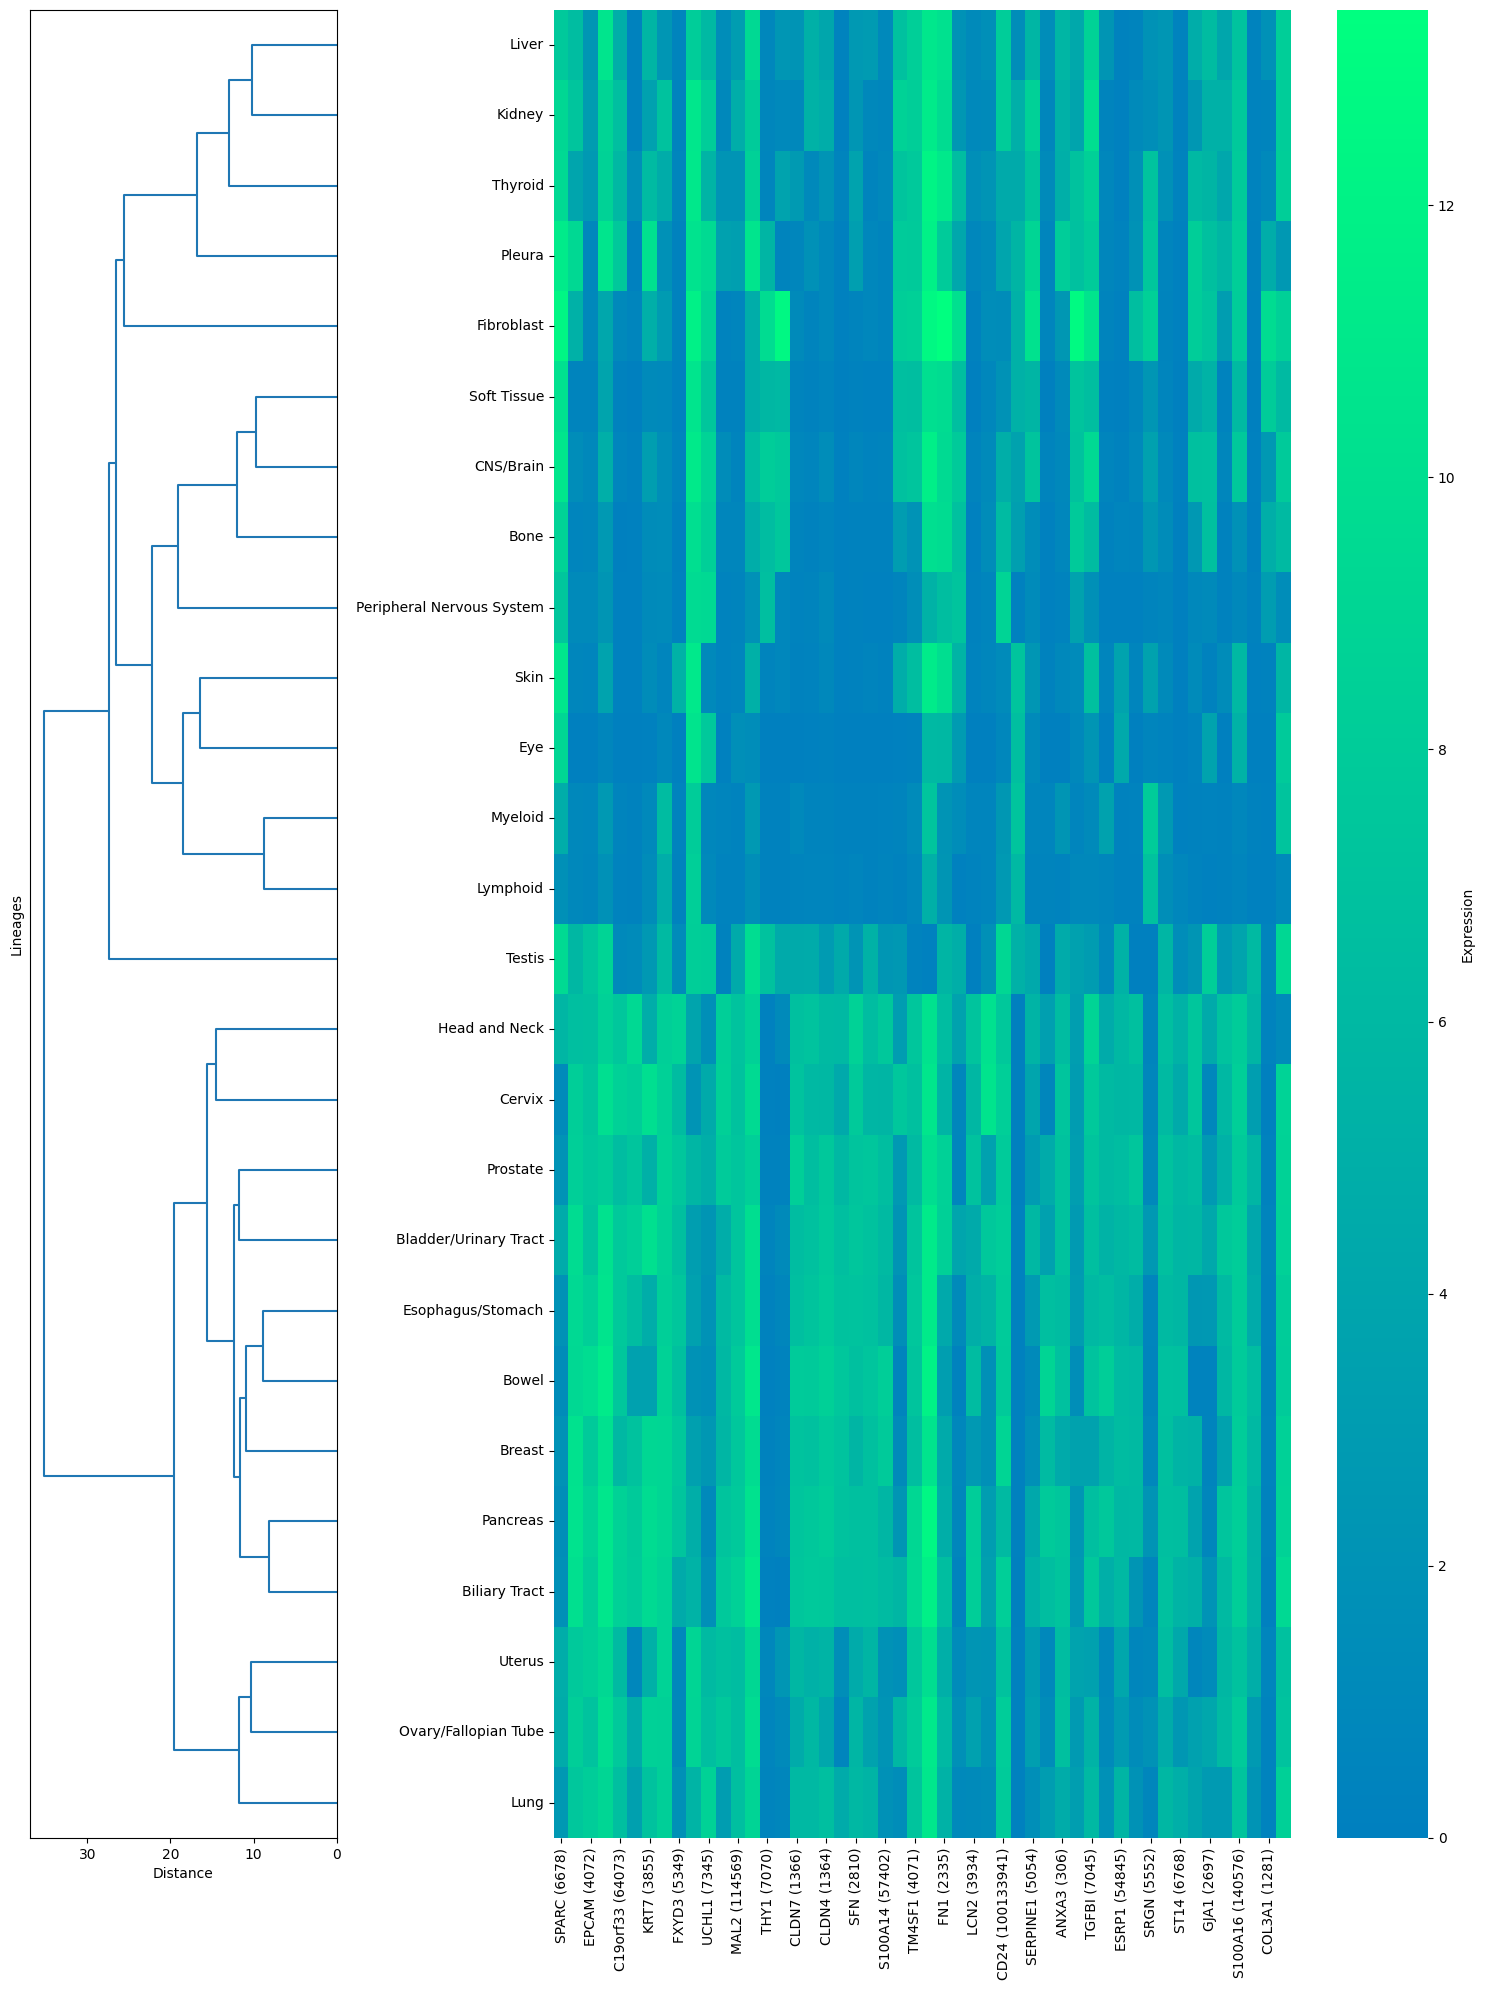

In [16]:
PE_lineages_reduced_top_50_var_linkage = linkage(PE_lineages_reduced_top_50_var, method='average', metric='euclidean')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 20), gridspec_kw={'width_ratios': [1, 3]})

dendr = dendrogram(PE_lineages_reduced_top_50_var_linkage, orientation='left', 
                   no_labels=True, ax=ax1, color_threshold=8)
ax1.set_ylabel('Lineages')
ax1.set_xlabel('Distance')

row_order = dendr['leaves']
PE_lineages_reduced_top_50_var_ordered = PE_lineages_reduced_top_50_var.iloc[row_order[::-1]]
sns.heatmap(PE_lineages_reduced_top_50_var_ordered, cmap='winter', center=0, ax=ax2, 
            cbar_kws={'label': 'Expression'})
ax2.set_ylabel('')

plt.tight_layout()
#plt.savefig("Hierarchical_lineages_reduced_top_50_var.pdf", format="pdf", bbox_inches='tight')
plt.show()

I will make a hierarchical clustering using all the genes avaliable (from the PE_grouped_lineages_reduced df). The PE_grouped_lineages_reduced df removed the lineages with less than 10 observations, and then indexed the dataframe by lineage.

In [17]:
PE_grouped_lineages_reduced

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
Lineage,,,,,,,,,,,,,,,,,,,,,
Biliary Tract,4.927954,0.000000,6.944848,2.504190,3.542903,0.031488,5.047847,6.113367,5.378403,3.634396,...,0.0,0.0,0.104572,0.991808,0.066474,0.491540,0.0,4.812407,1.168149,5.087336
Bladder/Urinary Tract,4.659077,0.000000,7.032316,2.537269,4.107742,0.074681,2.476338,6.052444,4.867139,3.877073,...,0.0,0.0,0.405183,0.972799,0.012140,0.628126,0.0,5.707711,0.035650,4.633541
Bone,4.623732,0.000000,6.643289,2.622912,4.291412,0.032226,2.486192,5.400340,4.253566,4.390179,...,0.0,0.0,0.013501,0.297445,0.730110,0.726421,0.0,5.525323,0.017769,4.769015
Bowel,4.690976,0.021177,6.780074,2.729533,3.696417,0.024610,0.148095,6.108635,5.519885,3.913943,...,0.0,0.0,0.000000,1.536506,0.034858,0.757726,0.0,5.581336,0.070297,4.472611
Breast,3.752716,0.000000,6.794234,2.979071,3.981159,0.057360,0.272187,5.709178,5.077833,4.097560,...,0.0,0.0,0.023059,1.246353,0.042116,0.814806,0.0,5.704593,0.066705,4.694028
CNS/Brain,4.456035,0.000000,6.753231,2.433684,3.953568,0.039396,2.836240,6.395482,4.338332,4.028202,...,0.0,0.0,0.009718,0.238017,0.066104,0.932624,0.0,5.649319,0.000018,4.875170
Cervix,4.516817,0.000000,7.205832,2.322337,3.584931,0.022978,1.349909,5.993335,4.923624,3.733854,...,0.0,0.0,0.305892,0.979381,0.031435,0.496646,0.0,5.493828,2.521676,4.792014
Esophagus/Stomach,4.403032,0.000000,6.868458,2.561295,3.835405,0.029803,1.273528,5.849975,5.587014,3.935869,...,0.0,0.0,0.038350,0.910744,0.032177,0.675246,0.0,5.791354,0.565310,4.249682
Eye,4.769170,0.000000,6.514472,2.578705,3.365117,0.000000,0.719294,5.914075,4.296595,3.981748,...,0.0,0.0,0.010150,0.365146,0.405737,0.442808,0.0,4.932503,0.000000,5.280004


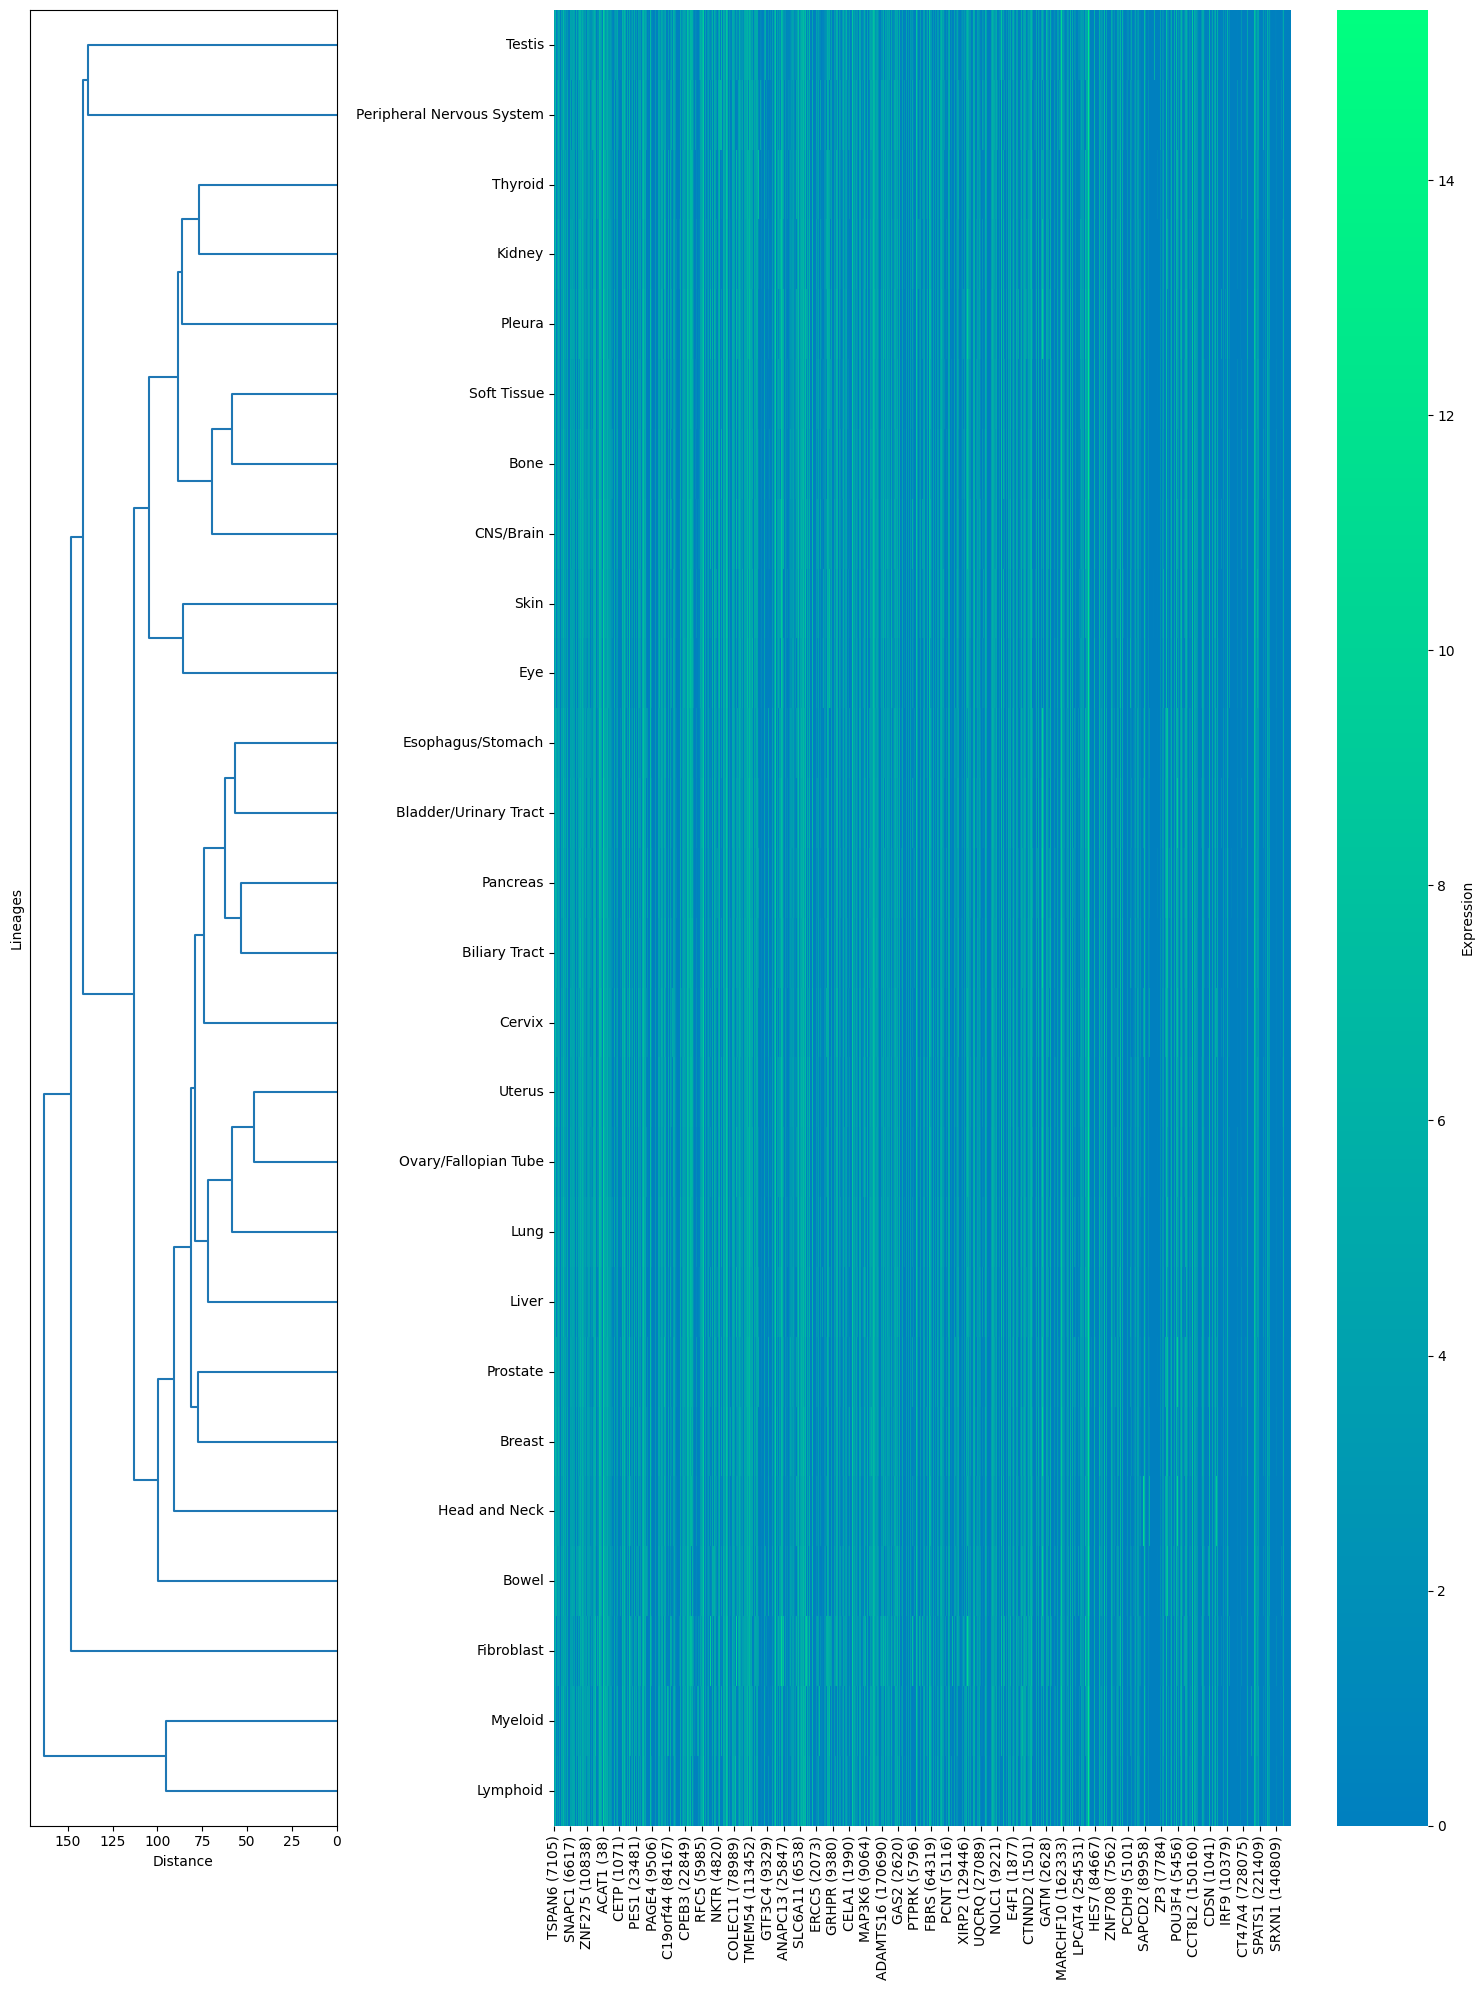

In [18]:
PE_grouped_lineages_reduced_linkage = linkage(PE_grouped_lineages_reduced, method='average', metric='euclidean')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 20), gridspec_kw={'width_ratios': [1, 3]})

dendr = dendrogram(PE_grouped_lineages_reduced_linkage, orientation='left', 
                   no_labels=True, ax=ax1, color_threshold=8)
ax1.set_ylabel('Lineages')
ax1.set_xlabel('Distance')

row_order = dendr['leaves']
PE_grouped_lineages_reduced_ordered = PE_grouped_lineages_reduced.iloc[row_order[::-1]]
sns.heatmap(PE_grouped_lineages_reduced_ordered, cmap='winter', center=0, ax=ax2, 
            cbar_kws={'label': 'Expression'})
ax2.set_ylabel('')

plt.tight_layout()
#plt.savefig("Hierarchical_lineages_reduced_top_50_var.pdf", format="pdf", bbox_inches='tight')
plt.show()

Using all the gene expression is unreadable, and because there are over 15,000 obersvations. I will trim down the df to contain the top 1,000 genes with the most variance in order to make the hierarchical clustering readable, and more informative then just using only top 50 most varied genes.

In [19]:
# make a dataframe that only take the top N genes that have the highest variance from the reduced Lineage df
PE_lineages_reduced_gene_variances = PE_grouped_lineages_reduced.var(axis=0, ddof=1)
PE_lineages_reduced_gene_variances_sorted = PE_lineages_reduced_gene_variances.sort_values(ascending=False)
PE_lineages_reduced_top_genes = PE_lineages_reduced_gene_variances_sorted.head(1000)
#print(PE_lineages_reduced_top_genes)

PE_lineages_reduced_top_1000_var = PE_grouped_lineages_reduced[PE_lineages_reduced_top_genes.index]
PE_lineages_reduced_top_1000_var

,SPARC (6678),KRT19 (3880),EPCAM (4072),KRT8 (3856),C19orf33 (64073),TACSTD2 (4070),KRT7 (3855),SPINT2 (10653),FXYD3 (5349),VIM (7431),...,PRUNE2 (158471),DSC3 (1825),TMEM132A (54972),PHOX2B (8929),MAP1LC3A (84557),ADAMTSL1 (92949),PBX1 (5087),TENM3 (55714),PLEKHO1 (51177),CPXM1 (56265)
Lineage,,,,,,,,,,,,,,,,,,,,,
Biliary Tract,1.732681,10.128668,8.146142,10.836637,8.546763,7.968773,9.484326,8.739789,4.419105,5.361191,...,0.272051,0.118811,5.038298,0.000000,2.269728,0.042719,3.288250,0.874171,1.663442,0.000000
Bladder/Urinary Tract,4.570533,9.670065,7.119254,10.287870,7.700291,8.352029,10.098344,8.548212,6.766111,3.158693,...,0.420243,2.151905,5.097547,0.000000,0.261956,0.127173,4.210074,1.527071,2.885731,0.014757
Bone,8.772608,0.593007,0.721158,2.644295,0.066628,0.129807,1.268147,1.373481,0.086119,10.059088,...,1.581949,0.024035,4.694674,0.000000,4.155320,0.362046,4.259920,2.104293,5.463825,0.848309
Bowel,1.305988,9.291509,9.763473,11.248847,7.522582,3.511038,3.479606,8.661853,6.752347,1.940125,...,0.664731,0.235873,4.248140,0.000000,3.218550,0.072113,2.857129,0.782749,1.242852,0.028005
Breast,1.974911,10.306198,7.861186,10.185594,5.898017,6.935024,9.227671,9.123118,7.646400,3.403734,...,0.443789,0.081750,6.126240,0.000000,1.667692,0.074263,5.023482,0.254407,2.522699,0.033515
CNS/Brain,10.791809,1.458284,0.854486,5.009307,0.579805,0.262194,3.154440,1.515435,0.403133,11.176285,...,3.108251,0.032267,5.410377,0.000000,4.086385,2.944816,3.545987,4.421289,4.692871,0.145530
Cervix,1.209547,8.213952,7.181623,10.074866,8.508551,8.168779,10.044388,8.559183,6.356273,2.163366,...,0.375578,2.198704,4.778551,0.000000,2.379290,0.031742,4.142885,0.436467,1.717255,0.018820
Esophagus/Stomach,1.975116,9.343247,8.314053,10.572525,7.766059,6.411955,4.774429,8.334852,7.401630,3.568491,...,0.544740,1.397938,4.928273,0.000000,1.442243,0.081902,2.871278,1.676596,2.201013,0.023166
Eye,9.105952,0.000000,0.065068,0.682643,0.000000,0.006481,0.178559,0.842852,0.000000,10.563765,...,4.485896,0.013436,4.201397,0.000000,3.580901,0.041185,2.310716,2.293027,4.192610,0.000000


# Figure 2

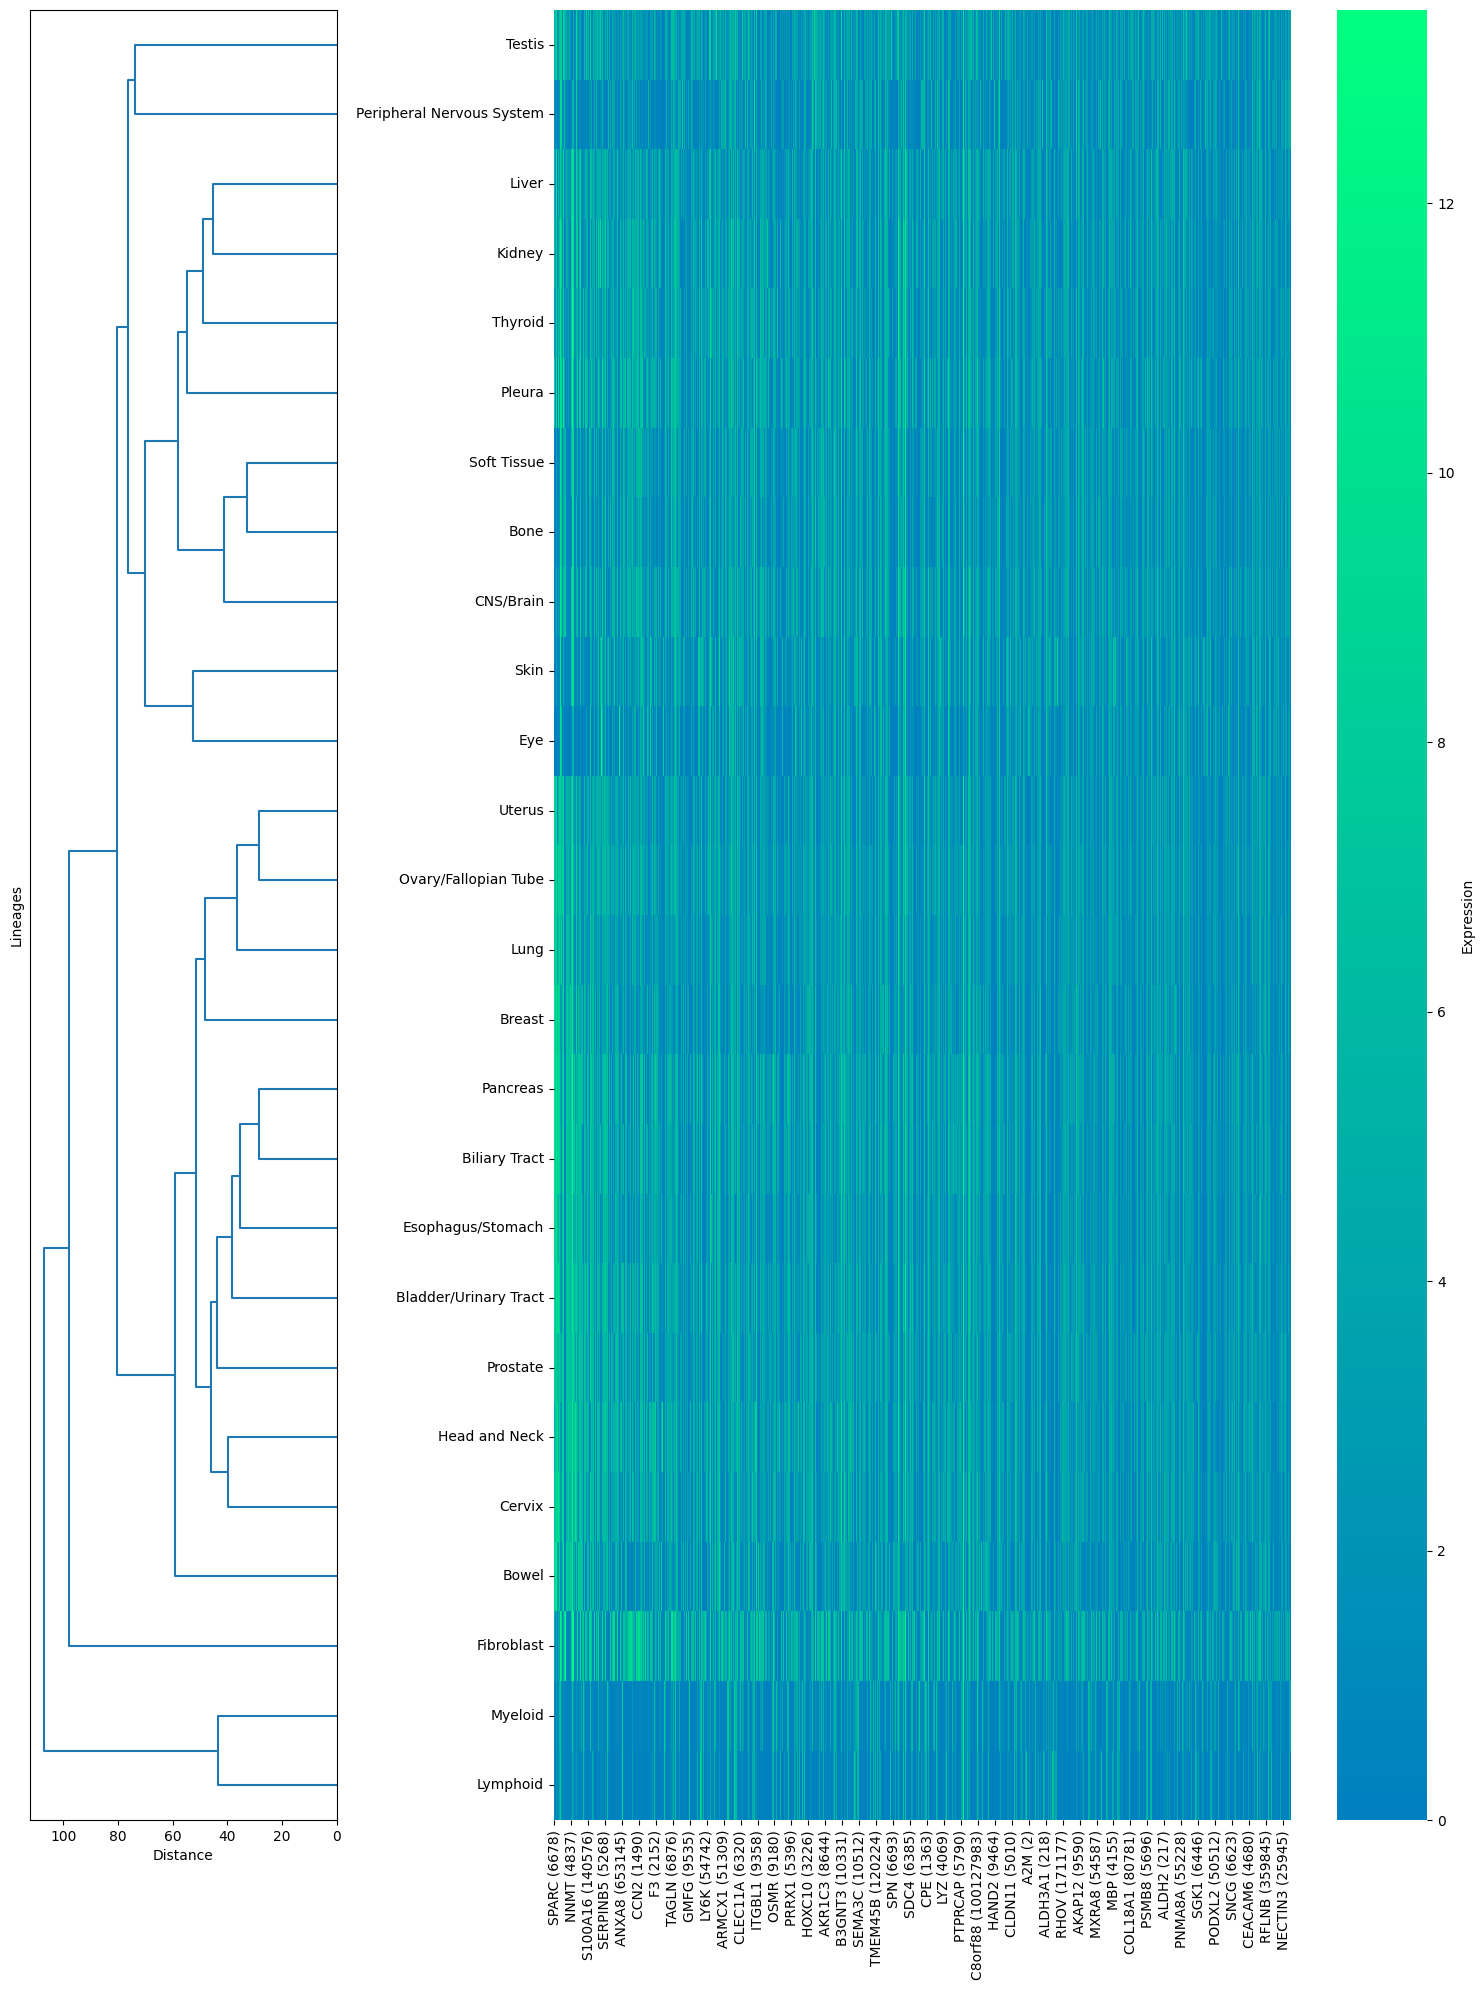

In [20]:
PE_lineages_reduced_top_1000_var_linkage = linkage(PE_lineages_reduced_top_1000_var, method='average', metric='euclidean')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 20), gridspec_kw={'width_ratios': [1, 3]})

dendr = dendrogram(PE_lineages_reduced_top_1000_var_linkage, orientation='left', 
                   no_labels=True, ax=ax1, color_threshold=8)
ax1.set_ylabel('Lineages')
ax1.set_xlabel('Distance')

row_order = dendr['leaves']
PE_lineages_reduced_top_1000_var_ordered = PE_lineages_reduced_top_1000_var.iloc[row_order[::-1]]
sns.heatmap(PE_lineages_reduced_top_1000_var_ordered, cmap='winter', center=0, ax=ax2, 
            cbar_kws={'label': 'Expression'})
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig("Hierarchical_lineages_reduced_top_1000_var.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Transpose pandas to run Hierarchical Clustering on Gene Expression

I need to swap the index column with all the gene expression columns in order to run hierarchical clustering that would make more sense than hierarchical clustering of the lineages (the hierarchical clustering could have biological significance, but would be more straightforward if I did hierarchical clustering on genes)

In [21]:
# swap the index and the columns of PE_lineages_reduced_top_1000_var and run hierarchical clustering
transposed_PE_lineages_reduced_top_1000_var = PE_lineages_reduced_top_1000_var.transpose()
transposed_PE_lineages_reduced_top_1000_var

Lineage,Biliary Tract,Bladder/Urinary Tract,Bone,Bowel,Breast,CNS/Brain,Cervix,Esophagus/Stomach,Eye,Fibroblast,...,Ovary/Fallopian Tube,Pancreas,Peripheral Nervous System,Pleura,Prostate,Skin,Soft Tissue,Testis,Thyroid,Uterus
SPARC (6678),1.732681,4.570533,8.772608,1.305988,1.974911,10.791809,1.209547,1.975116,9.105952,12.462576,...,4.592319,1.499971,7.405759,11.294723,2.033589,10.746277,10.182245,9.467531,9.407103,4.825973
KRT19 (3880),10.128668,9.670065,0.593007,9.291509,10.306198,1.458284,8.213952,9.343247,0.000000,5.155369,...,8.224981,10.493575,1.058072,9.282119,8.343217,0.676652,0.505758,5.775496,3.948873,7.664802
EPCAM (4072),8.146142,7.119254,0.721158,9.763473,7.861186,0.854486,7.181623,8.314053,0.065068,0.866407,...,7.095513,8.665677,1.088785,0.824715,7.461226,0.578083,0.515182,7.338637,2.637792,8.217717
KRT8 (3856),10.836637,10.287870,2.644295,11.248847,10.185594,5.009307,10.074866,10.572525,0.682643,4.122349,...,9.764323,10.892930,2.297839,10.674178,8.070003,3.732336,3.858083,8.883420,8.611733,9.285477
C19orf33 (64073),8.546763,7.700291,0.066628,7.522582,5.898017,0.579805,8.508551,7.766059,0.000000,0.984774,...,7.732771,8.607708,0.178706,7.582133,6.467361,0.194020,0.285777,1.049513,5.978080,6.163879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ADAMTSL1 (92949),0.042719,0.127173,0.362046,0.072113,0.074263,2.944816,0.031742,0.081902,0.041185,5.153484,...,0.246981,0.072940,2.350816,1.087505,0.104366,0.161017,2.375166,0.405394,3.476405,0.170838
PBX1 (5087),3.288250,4.210074,4.259920,2.857129,5.023482,3.545987,4.142885,2.871278,2.310716,3.351903,...,3.231031,3.047760,4.366546,4.404952,2.250552,0.562246,3.211985,4.654529,2.381179,2.225041
TENM3 (55714),0.874171,1.527071,2.104293,0.782749,0.254407,4.421289,0.436467,1.676596,2.293027,3.748331,...,2.727722,0.561945,3.818140,4.048362,0.274458,2.632387,3.332254,3.025832,3.127725,2.732429
PLEKHO1 (51177),1.663442,2.885731,5.463825,1.242852,2.522699,4.692871,1.717255,2.201013,4.192610,5.305327,...,3.341165,1.809480,5.508708,4.346559,2.232903,3.807128,5.138730,3.122273,4.713630,3.600688


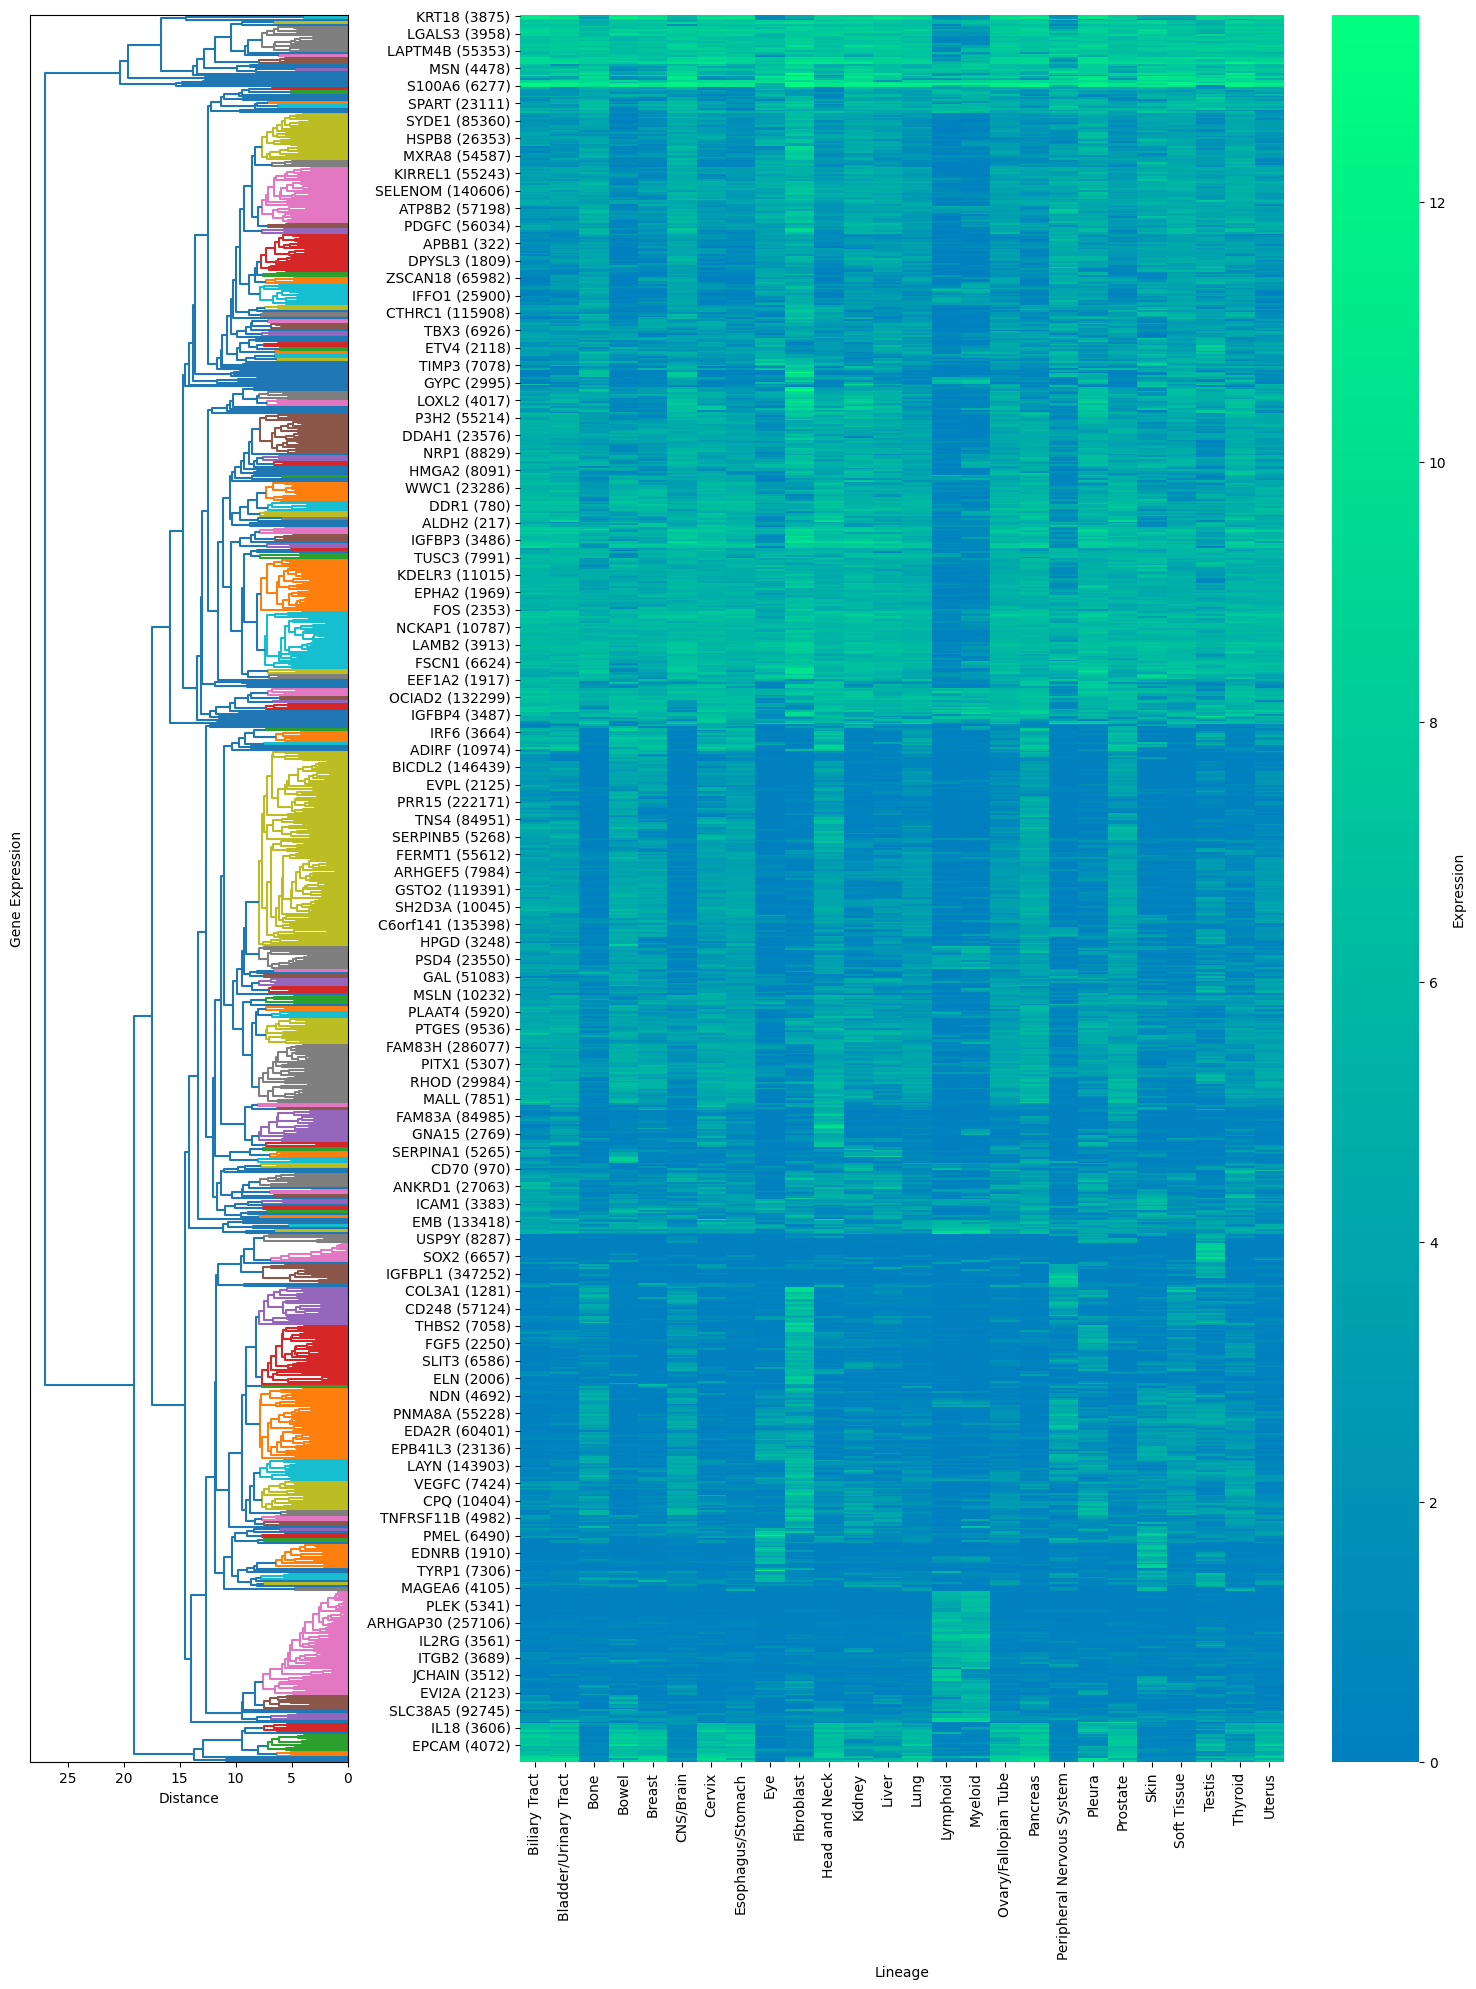

In [22]:
transposed_PE_lineages_reduced_top_1000_var_linkage = linkage(transposed_PE_lineages_reduced_top_1000_var, method='average', metric='euclidean')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 20), gridspec_kw={'width_ratios': [1, 3]})

dendr = dendrogram(transposed_PE_lineages_reduced_top_1000_var_linkage, orientation='left', 
                   no_labels=True, ax=ax1, color_threshold=8)
ax1.set_ylabel('Gene Expression')
ax1.set_xlabel('Distance')

row_order = dendr['leaves']
transposed_PE_lineages_reduced_top_1000_var_ordered = transposed_PE_lineages_reduced_top_1000_var.iloc[row_order[::-1]]
sns.heatmap(transposed_PE_lineages_reduced_top_1000_var_ordered, cmap='winter', center=0, ax=ax2, 
            cbar_kws={'label': 'Expression'})
ax2.set_ylabel('')

plt.tight_layout()
#plt.savefig("Hierarchical_lineages_reduced_top_1000_var.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [23]:
# make a dataframe that only take the top N genes that have the highest variance from the reduced Lineage df
PE_lineages_reduced_gene_variances = PE_grouped_lineages_reduced.var(axis=0, ddof=1)
PE_lineages_reduced_gene_variances_sorted = PE_lineages_reduced_gene_variances.sort_values(ascending=False)
PE_lineages_reduced_top_genes = PE_lineages_reduced_gene_variances_sorted.head(500)
#print(PE_lineages_reduced_top_genes)

PE_lineages_reduced_top_500_var = PE_grouped_lineages_reduced[PE_lineages_reduced_top_genes.index]
PE_lineages_reduced_top_500_var

,SPARC (6678),KRT19 (3880),EPCAM (4072),KRT8 (3856),C19orf33 (64073),TACSTD2 (4070),KRT7 (3855),SPINT2 (10653),FXYD3 (5349),VIM (7431),...,EIF1AY (9086),STEAP1 (26872),APOL1 (8542),RNF128 (79589),DENND1C (79958),CTSL (1514),AIF1 (199),HNMT (3176),SYT11 (23208),TFAP2A (7020)
Lineage,,,,,,,,,,,,,,,,,,,,,
Biliary Tract,1.732681,10.128668,8.146142,10.836637,8.546763,7.968773,9.484326,8.739789,4.419105,5.361191,...,0.000000,5.069298,5.028307,4.081095,3.710039,6.710050,0.000000,4.810005,0.278821,3.919435
Bladder/Urinary Tract,4.570533,9.670065,7.119254,10.287870,7.700291,8.352029,10.098344,8.548212,6.766111,3.158693,...,0.138869,3.042672,4.360228,3.495800,3.066334,6.648063,0.093589,3.389326,0.260287,4.253641
Bone,8.772608,0.593007,0.721158,2.644295,0.066628,0.129807,1.268147,1.373481,0.086119,10.059088,...,0.216015,6.222664,0.529920,0.125897,0.266710,6.101614,0.094437,3.402411,3.444843,2.295729
Bowel,1.305988,9.291509,9.763473,11.248847,7.522582,3.511038,3.479606,8.661853,6.752347,1.940125,...,0.111711,5.221200,2.088471,4.820082,4.512379,4.241360,0.141005,4.921946,0.114374,1.884082
Breast,1.974911,10.306198,7.861186,10.185594,5.898017,6.935024,9.227671,9.123118,7.646400,3.403734,...,0.016245,2.018680,1.336798,0.816312,3.552303,5.863220,0.086649,3.179412,0.128285,5.433490
CNS/Brain,10.791809,1.458284,0.854486,5.009307,0.579805,0.262194,3.154440,1.515435,0.403133,11.176285,...,1.689562,4.017753,3.253301,0.332279,0.182952,7.388259,0.066279,3.607118,4.146068,3.195762
Cervix,1.209547,8.213952,7.181623,10.074866,8.508551,8.168779,10.044388,8.559183,6.356273,2.163366,...,0.000000,2.240708,3.230423,0.050236,2.995128,6.642289,0.000000,0.259083,0.206577,5.465481
Esophagus/Stomach,1.975116,9.343247,8.314053,10.572525,7.766059,6.411955,4.774429,8.334852,7.401630,3.568491,...,0.135318,4.452577,3.238709,3.158926,3.360337,5.862107,0.074327,3.404765,0.122324,4.015208
Eye,9.105952,0.000000,0.065068,0.682643,0.000000,0.006481,0.178559,0.842852,0.000000,10.563765,...,0.000000,3.273890,0.068508,0.404239,0.215077,7.447816,0.000000,0.557193,1.273864,5.373559


In [24]:
# swap the index and the columns of PE_lineages_reduced_top_500_var and run hierarchical clustering
transposed_PE_lineages_reduced_top_500_var = PE_lineages_reduced_top_500_var.transpose()
transposed_PE_lineages_reduced_top_500_var

Lineage,Biliary Tract,Bladder/Urinary Tract,Bone,Bowel,Breast,CNS/Brain,Cervix,Esophagus/Stomach,Eye,Fibroblast,...,Ovary/Fallopian Tube,Pancreas,Peripheral Nervous System,Pleura,Prostate,Skin,Soft Tissue,Testis,Thyroid,Uterus
SPARC (6678),1.732681,4.570533,8.772608,1.305988,1.974911,10.791809,1.209547,1.975116,9.105952,12.462576,...,4.592319,1.499971,7.405759,11.294723,2.033589,10.746277,10.182245,9.467531,9.407103,4.825973
KRT19 (3880),10.128668,9.670065,0.593007,9.291509,10.306198,1.458284,8.213952,9.343247,0.000000,5.155369,...,8.224981,10.493575,1.058072,9.282119,8.343217,0.676652,0.505758,5.775496,3.948873,7.664802
EPCAM (4072),8.146142,7.119254,0.721158,9.763473,7.861186,0.854486,7.181623,8.314053,0.065068,0.866407,...,7.095513,8.665677,1.088785,0.824715,7.461226,0.578083,0.515182,7.338637,2.637792,8.217717
KRT8 (3856),10.836637,10.287870,2.644295,11.248847,10.185594,5.009307,10.074866,10.572525,0.682643,4.122349,...,9.764323,10.892930,2.297839,10.674178,8.070003,3.732336,3.858083,8.883420,8.611733,9.285477
C19orf33 (64073),8.546763,7.700291,0.066628,7.522582,5.898017,0.579805,8.508551,7.766059,0.000000,0.984774,...,7.732771,8.607708,0.178706,7.582133,6.467361,0.194020,0.285777,1.049513,5.978080,6.163879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTSL (1514),6.710050,6.648063,6.101614,4.241360,5.863220,7.388259,6.642289,5.862107,7.447816,8.060414,...,6.253373,6.209268,5.711174,7.370581,6.435960,7.714033,6.889004,6.438435,7.442312,6.275853
AIF1 (199),0.000000,0.093589,0.094437,0.141005,0.086649,0.066279,0.000000,0.074327,0.000000,0.053112,...,0.104857,0.117207,0.027611,0.042062,0.000000,0.000000,0.000000,0.167402,0.028409,0.091891
HNMT (3176),4.810005,3.389326,3.402411,4.921946,3.179412,3.607118,0.259083,3.404765,0.557193,3.797239,...,1.227291,4.817076,1.544568,0.331653,2.944364,3.665116,3.210766,3.280338,2.746348,0.926198
SYT11 (23208),0.278821,0.260287,3.444843,0.114374,0.128285,4.146068,0.206577,0.122324,1.273864,4.430855,...,1.256310,0.343529,5.872611,1.138154,0.298024,2.901298,3.736449,0.633502,1.688613,0.243484


# Figure 3

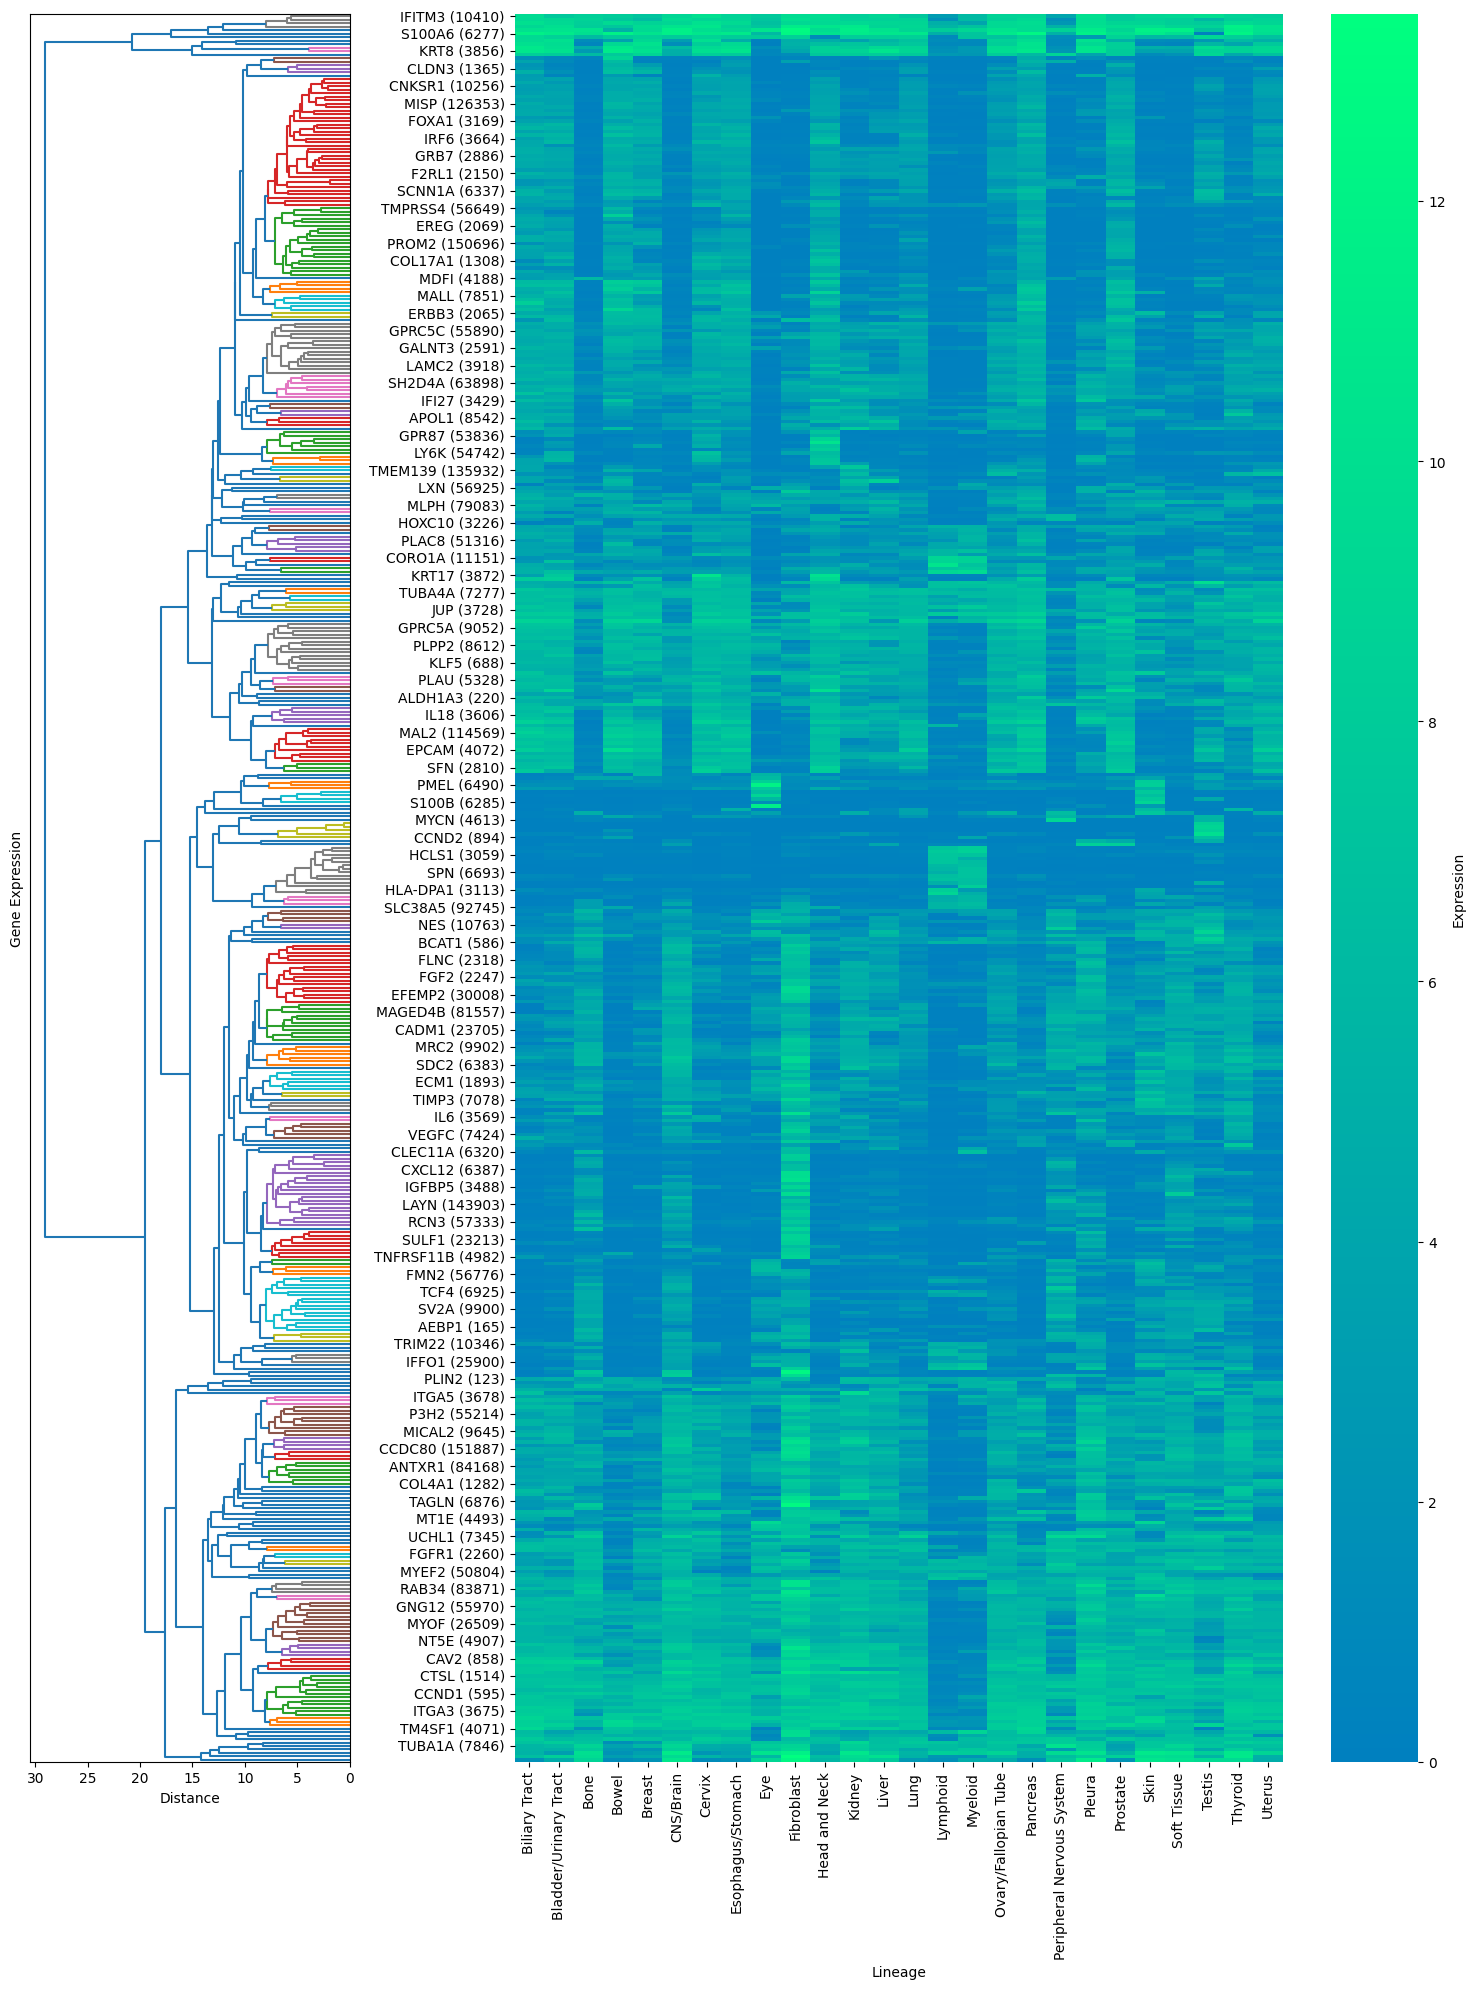

In [25]:
transposed_PE_lineages_reduced_top_500_var_linkage = linkage(transposed_PE_lineages_reduced_top_500_var, method='average', metric='euclidean')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 20), gridspec_kw={'width_ratios': [1, 3]})

dendr = dendrogram(transposed_PE_lineages_reduced_top_500_var_linkage, orientation='left', 
                   no_labels=True, ax=ax1, color_threshold=8)
ax1.set_ylabel('Gene Expression')
ax1.set_xlabel('Distance')

row_order = dendr['leaves']
transposed_PE_lineages_reduced_top_500_var_ordered = transposed_PE_lineages_reduced_top_500_var.iloc[row_order[::-1]]
sns.heatmap(transposed_PE_lineages_reduced_top_500_var_ordered, cmap='winter', center=0, ax=ax2, 
            cbar_kws={'label': 'Expression'})
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig("Hierarchical_expression_top_500_var.pdf", format="pdf", bbox_inches='tight')
plt.show()

# t-SNE

We will run a tSNE on our CCLE data, because that dataset has many variable thats might should some trends (either expected or otherwise).

For example, in Models / Profiles / Expression, there is data for the Age, Gender, Age group, even Metasis or otherwise that could provide important information for understanding the contributing factors to the specific cancer cell line.

Since our data is multidimensional, it might be useful to run a t-SNE to reduce the dimensions of our dataset.

# Sources

This cell will help me keep track of useful tutorials in learning to run, understand, and interpret the tSNE.

This source is for learning how to make a tSNE:
https://builtin.com/data-science/tsne-python

This source is for with plotting seaborn plots (moving the label):
https://seaborn.pydata.org/generated/seaborn.move_legend.html

In [26]:
from __future__ import print_function
import time
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import seaborn as sns

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Merging all datasets for t-SNE

The below code is manipulating the datasets from CCLE to retain all the potentially important data first, and removing other data (such as Cell Line Name, or Patient ID) which most likely would not contribute initially.

Some of the code is repeated from earlier; however, some changes were made in order to retain more metadata.

In [27]:
# Reducing the Models data
Models = pd.read_csv('Model.csv', low_memory=False)
#list(Models)

Models_Meta_data = ['PatientID','CellLineName','StrippedCellLineName','DepmapModelType','OncotreeCode',
 'PatientSubtypeFeatures','RRID','PrimaryOrMetastasis','SampleCollectionSite','SourceType','SourceDetail',
 'CatalogNumber','ModelType','TissueOrigin','ModelDerivationMaterial','ModelTreatment','PatientTreatmentStatus',
 'PatientTreatmentType','PatientTreatmentDetails','Stage','StagingSystem','PatientTumorGrade',
 'PatientTreatmentResponse','GrowthPattern','OnboardedMedia','FormulationID','SerumFreeMedia','PlateCoating',
 'EngineeredModel','EngineeredModelDetails','CulturedResistanceDrug','PublicComments','CCLEName','HCMIID',
 'PediatricModelType','ModelAvailableInDbgap','ModelSubtypeFeatures','WTSIMasterCellID','SangerModelID',
 'COSMICID','ModelIDAlias']
meta_model_cols = [c for c in Models_Meta_data if c in Models.columns]
model_reduced_cols = gene_cols = [c for c in Models.columns if c not in meta_model_cols]
Models_reduced = Models[model_reduced_cols]
#Models_reduced.drop_duplicates(keep='first', inplace=True)
#Models_reduced

# index Expressions_reduced by 'ModelID'
Models_reduced_Index = Models_reduced.set_index("ModelID")
Models_reduced_Index

,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,Age,AgeCategory,Sex,PatientRace
ModelID,,,,,,,
ACH-000001,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
ACH-000002,Myeloid,Acute Myeloid Leukemia,AML with Myelodysplasia-Related Changes,36.0,Adult,Female,caucasian
ACH-000003,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,72.0,Adult,Male,caucasian
ACH-000004,Myeloid,Acute Myeloid Leukemia,"AML, NOS",30.0,Adult,Male,caucasian
ACH-000005,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,30.0,Adult,Male,caucasian
...,...,...,...,...,...,...,...
ACH-003473,Soft Tissue,Rhabdomyosarcoma,Embryonal Rhabdomyosarcoma,1.0,Pediatric,Female,caucasian
ACH-003474,Head and Neck,Head and Neck Squamous Cell Carcinoma,Head and Neck Squamous Cell Carcinoma,77.0,Adult,Male,caucasian
ACH-003475,Head and Neck,Head and Neck Squamous Cell Carcinoma,Head and Neck Squamous Cell Carcinoma,76.0,Adult,Female,caucasian


In [28]:
# Reducing the Profiles data
Profiles = pd.read_csv('OmicsProfiles.csv', low_memory=False)
#list(Profiles)

Profiles_Meta_data= ['IsDefaultEntryForModel','StrippedCellLineName','DepMapCode','ModelConditionID',
 'IsDefaultEntryForMC','SourceModelCondition','CellFormat','GrowthMedia','GrowthPattern','ProfileID',
 'SequencingPlatform','DataType','Stranded','SharedToDbGaP','SequencingDate'] #'SequencingID' 'ModelID'
profiles_model_cols = [c for c in Profiles_Meta_data if c in Profiles.columns]
profiles_reduced_cols = gene_cols = [c for c in Profiles.columns if c not in profiles_model_cols]
Profiles_reduced = Profiles[profiles_reduced_cols]
#Profiles_reduced_duplicates = Profiles_reduced.drop_duplicates(keep='first') #, inplace=True
#Profiles_reduced

# index Expressions_reduced by 'SequencingID'
Profiles_reduced_Model_Index = Profiles_reduced.set_index("ModelID")
Profiles_reduced_Model_Index

,Lineage,SequencingID
ModelID,,
ACH-000001,Ovary/Fallopian Tube,CDS-VqxBGH
ACH-000001,Ovary/Fallopian Tube,CDS-1pLoxn
ACH-000001,Ovary/Fallopian Tube,CDS-C3gZIu
ACH-000013,Ovary/Fallopian Tube,CDS-qqF7T8
ACH-000013,Ovary/Fallopian Tube,CDS-FvwPIb
...,...,...
ACH-003161,Pancreas,CDS-k5gIOX
ACH-003191,Bone,CDS-KoBwnR
ACH-003191,Bone,CDS-5xnEtM


In [29]:
# combine profiles and models to create a dataset that has the meta data of Age etc.
Models_Profiles_reduced = pd.merge(Profiles_reduced_Model_Index, Models_reduced_Index, on="ModelID")
Models_Profiles_reduced

,Lineage,SequencingID,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,Age,AgeCategory,Sex,PatientRace
ModelID,,,,,,,,,
ACH-000001,Ovary/Fallopian Tube,CDS-VqxBGH,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
ACH-000001,Ovary/Fallopian Tube,CDS-1pLoxn,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
ACH-000001,Ovary/Fallopian Tube,CDS-C3gZIu,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
ACH-000013,Ovary/Fallopian Tube,CDS-qqF7T8,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
ACH-000013,Ovary/Fallopian Tube,CDS-FvwPIb,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
...,...,...,...,...,...,...,...,...,...
ACH-003161,Pancreas,CDS-k5gIOX,Pancreas,Non-Cancerous,Immortalized Pancreatic Stromal Cells,NaN,Unknown,NaN,NaN
ACH-003191,Bone,CDS-KoBwnR,Bone,Giant Cell Tumor of Bone,Giant Cell Tumor of Bone,70.0,Adult,Male,NaN
ACH-003191,Bone,CDS-5xnEtM,Bone,Giant Cell Tumor of Bone,Giant Cell Tumor of Bone,70.0,Adult,Male,NaN


In [30]:
# we will change index to SequenceID in order to merge with the Expression dataset
Models_Profiles_reduced_Index = Models_Profiles_reduced.set_index("SequencingID")
Models_Profiles_reduced_Index

,Lineage,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,Age,AgeCategory,Sex,PatientRace
SequencingID,,,,,,,,
CDS-VqxBGH,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
CDS-1pLoxn,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
CDS-C3gZIu,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
CDS-qqF7T8,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
CDS-FvwPIb,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian
...,...,...,...,...,...,...,...,...
CDS-k5gIOX,Pancreas,Pancreas,Non-Cancerous,Immortalized Pancreatic Stromal Cells,NaN,Unknown,NaN,NaN
CDS-KoBwnR,Bone,Bone,Giant Cell Tumor of Bone,Giant Cell Tumor of Bone,70.0,Adult,Male,NaN
CDS-5xnEtM,Bone,Bone,Giant Cell Tumor of Bone,Giant Cell Tumor of Bone,70.0,Adult,Male,NaN


In [31]:
# Reducing the Expression data
Expression = pd.read_csv('OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv', low_memory=False)
#list(Expression)

Expressions_Meta_data = ['Unnamed: 0','IsDefaultEntryForModel','ModelConditionID','ModelID',
                         'IsDefaultEntryForMC']#'SequencingID' 'ModelID'
expressions_model_cols = [c for c in Expressions_Meta_data if c in Expression.columns]
expressions_reduced_cols = gene_cols = [c for c in Expression.columns if c not in expressions_model_cols]
Expressions_reduced = Expression[expressions_reduced_cols]
#Expressions_reduced.drop_duplicates(keep='first', inplace=True)
#Expressions_reduced

# index Expressions_reduced by 'SequencingID'
Expressions_reduced_Index = Expressions_reduced.set_index("SequencingID")
Expressions_reduced_Index

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
SequencingID,,,,,,,,,,,,,,,,,,,,,
CDS-010xbm,4.956577,0.000000,7.577648,3.179411,4.765742,0.037483,1.510547,3.103039,6.697482,4.852304,...,0.0,0.000000,0.414727,0.077634,1.113094,0.411901,0.0,5.134808,1.214541,4.315653
CDS-02TzJp,4.954992,0.617243,7.334747,2.783576,3.736280,0.000000,0.149060,3.855960,4.377061,3.466249,...,0.0,0.000000,0.029840,0.000000,1.262156,1.026871,0.0,5.951231,0.007227,4.251060
CDS-0693hw,3.421952,0.000000,7.546069,2.615880,4.476233,0.064571,1.397491,6.833915,3.980336,3.437154,...,0.0,0.000000,0.127768,0.105594,0.413829,0.540575,0.0,4.205971,0.030894,2.783448
CDS-07Plat,5.196729,0.000000,6.362268,2.144996,3.087183,0.036001,5.118850,7.013295,6.177005,3.509987,...,0.0,0.000000,0.075396,0.932918,0.000000,0.511978,0.0,4.510747,3.223597,5.106595
CDS-08FOcu,4.651643,0.000000,5.946408,2.454515,1.852111,0.000000,7.680796,6.156866,5.042574,3.258451,...,0.0,0.000000,0.012012,0.000000,1.006470,0.729221,0.0,4.922916,0.150926,4.661556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDS-zsS3zE,3.770702,0.000000,7.380245,1.803405,4.191989,0.013924,4.023557,6.989366,4.815309,4.503457,...,0.0,0.000000,0.032260,0.890296,0.185355,0.211497,0.0,5.602071,0.000000,7.062305
CDS-zsp0NA,4.886794,0.000000,7.245942,2.187771,3.611621,0.020211,3.658680,6.957810,5.617589,3.420170,...,0.0,0.000000,1.727733,0.311457,0.179430,0.468641,0.0,5.290513,0.030359,5.632411
CDS-zvrgDc,5.721963,0.000000,8.299822,3.008067,4.362596,0.000000,4.620053,7.230376,4.995132,3.555571,...,0.0,0.000000,0.002292,2.102581,0.005078,0.382775,0.0,4.417502,0.008285,5.242202


In [32]:
# merge the sequence ID indexed datasets together
MPE_reduced = pd.merge(Models_Profiles_reduced_Index, Expressions_reduced_Index, on="SequencingID")
MPE_reduced

,Lineage,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,Age,AgeCategory,Sex,PatientRace,TSPAN6 (7105),TNMD (64102),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
SequencingID,,,,,,,,,,,,,,,,,,,,,
CDS-VqxBGH,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian,5.490942,0.00000,...,0.000000,0.063369,0.029583,1.521764,1.713788,0.798202,0.0,6.552359,0.000000,5.515829
CDS-qqF7T8,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian,5.097872,0.06319,...,0.000000,0.029822,0.024877,0.267380,1.348232,0.579396,0.0,6.040605,0.000000,4.932930
CDS-kpzIIP,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,45.0,Adult,Female,caucasian,4.262486,0.00000,...,0.000000,0.101602,0.016118,1.491207,0.667077,0.503766,0.0,5.349256,0.000000,4.013605
CDS-Dc4piF,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,75.0,Adult,Female,NaN,5.250852,0.00000,...,0.000000,0.034469,0.245185,0.278430,0.429859,1.482270,0.0,7.178595,0.000000,5.413540
CDS-PP0aCP,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,45.0,Adult,Female,asian,5.963250,0.00000,...,0.029468,0.000000,0.500686,1.434940,0.244384,1.078924,0.0,5.251227,2.323428,4.913272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDS-jsRCMr,Hair,Hair,Non-Cancerous,Immortalized Hair Follicle Inner Root Sheath C...,NaN,Unknown,NaN,NaN,4.737503,0.00000,...,0.000000,0.000000,0.020134,0.458883,0.090925,0.789112,0.0,5.322220,0.916229,4.202488
CDS-lp24FU,Hair,Hair,Non-Cancerous,Immortalized Hair Germinal Matrix Cells,NaN,Unknown,NaN,NaN,4.940200,0.00000,...,0.000000,0.000000,0.036527,0.383698,0.188350,1.255990,0.0,5.702453,4.077294,4.920903
CDS-k5gIOX,Pancreas,Pancreas,Non-Cancerous,Immortalized Pancreatic Stromal Cells,NaN,Unknown,NaN,NaN,4.854075,0.00000,...,0.000000,0.000000,0.000000,0.171379,0.000000,0.632722,0.0,5.696475,2.655052,4.967081


In [33]:
# remove lineages that only have >=10 amount of observations
lineages = MPE_reduced["Lineage"]
class_counts = MPE_reduced[lineages.name].value_counts()
classes_to_keep = class_counts[class_counts >= 10].index
MPE_lineages_reduced = MPE_reduced[MPE_reduced[lineages.name].isin(classes_to_keep)]

#MPE_lineages_reduced["Lineage"].value_counts()
MPE_lineages_reduced

,Lineage,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,Age,AgeCategory,Sex,PatientRace,TSPAN6 (7105),TNMD (64102),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
SequencingID,,,,,,,,,,,,,,,,,,,,,
CDS-VqxBGH,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian,5.490942,0.00000,...,0.000000,0.063369,0.029583,1.521764,1.713788,0.798202,0.0,6.552359,0.000000,5.515829
CDS-qqF7T8,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,60.0,Adult,Female,caucasian,5.097872,0.06319,...,0.000000,0.029822,0.024877,0.267380,1.348232,0.579396,0.0,6.040605,0.000000,4.932930
CDS-kpzIIP,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,45.0,Adult,Female,caucasian,4.262486,0.00000,...,0.000000,0.101602,0.016118,1.491207,0.667077,0.503766,0.0,5.349256,0.000000,4.013605
CDS-Dc4piF,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,75.0,Adult,Female,NaN,5.250852,0.00000,...,0.000000,0.034469,0.245185,0.278430,0.429859,1.482270,0.0,7.178595,0.000000,5.413540
CDS-PP0aCP,Ovary/Fallopian Tube,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,45.0,Adult,Female,asian,5.963250,0.00000,...,0.029468,0.000000,0.500686,1.434940,0.244384,1.078924,0.0,5.251227,2.323428,4.913272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDS-xszVVB,Liver,Liver,Non-Cancerous,Immortalized Liver Cells,NaN,Fetus,NaN,NaN,4.149186,0.00000,...,0.000000,0.000000,0.057646,0.363143,0.214947,0.656728,0.0,5.298468,0.002847,4.164078
CDS-YgH5wL,Lung,Lung,Non-Cancerous,Immortalized MPLC Cells,NaN,Fetus,Male,NaN,3.954382,0.00000,...,0.000000,0.000000,0.000000,0.506279,0.000000,1.233084,0.0,5.484709,0.031539,3.979440
CDS-k5gIOX,Pancreas,Pancreas,Non-Cancerous,Immortalized Pancreatic Stromal Cells,NaN,Unknown,NaN,NaN,4.854075,0.00000,...,0.000000,0.000000,0.000000,0.171379,0.000000,0.632722,0.0,5.696475,2.655052,4.967081


# Running a t-SNE on our merged dataframe

Will run a t-SNE on our merged dataframe 'MPE_lineages_reduced'. This dataframe retains more of the metadata than the dataframe previously.

I have a df that combines the meta data from the Models dataset (Age, Sex, Primary Disease, etc.).

However, I was not able to groupby lineage so far, because the age between the different sequencing IDs are differing, so I cannot just take the median or something because I feel like we lose valuable information if we did that.

In [34]:
# removed the categorical variables, can color the tSNE later with this meta data
meta_data_MPE = ['Lineage', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'Age', 'AgeCategory',
                'Sex', 'PatientRace']

MPE_meta_reduced = MPE_lineages_reduced.drop(meta_data_MPE, axis=1)
MPE_meta_reduced

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
SequencingID,,,,,,,,,,,,,,,,,,,,,
CDS-VqxBGH,5.490942,0.00000,7.558490,2.306714,4.423215,0.046938,1.042448,5.904893,5.125176,3.869477,...,0.000000,0.063369,0.029583,1.521764,1.713788,0.798202,0.0,6.552359,0.000000,5.515829
CDS-qqF7T8,5.097872,0.06319,7.709780,1.959236,3.633408,0.024325,2.118420,5.478529,4.358579,3.164733,...,0.000000,0.029822,0.024877,0.267380,1.348232,0.579396,0.0,6.040605,0.000000,4.932930
CDS-kpzIIP,4.262486,0.00000,6.477196,2.490498,3.639012,0.085499,4.061379,4.328980,4.288233,3.426434,...,0.000000,0.101602,0.016118,1.491207,0.667077,0.503766,0.0,5.349256,0.000000,4.013605
CDS-Dc4piF,5.250852,0.00000,6.504501,2.288766,3.923748,0.025441,0.883857,6.570823,4.980185,3.638595,...,0.000000,0.034469,0.245185,0.278430,0.429859,1.482270,0.0,7.178595,0.000000,5.413540
CDS-PP0aCP,5.963250,0.00000,6.409170,2.951543,4.515763,0.020494,3.699918,5.588877,3.656428,3.870582,...,0.029468,0.000000,0.500686,1.434940,0.244384,1.078924,0.0,5.251227,2.323428,4.913272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDS-xszVVB,4.149186,0.00000,8.066105,2.823499,5.061612,0.021954,3.467214,6.190050,4.885613,4.465635,...,0.000000,0.000000,0.057646,0.363143,0.214947,0.656728,0.0,5.298468,0.002847,4.164078
CDS-YgH5wL,3.954382,0.00000,6.916286,3.020931,3.598175,0.113647,7.875301,6.533104,4.832860,3.752363,...,0.000000,0.000000,0.000000,0.506279,0.000000,1.233084,0.0,5.484709,0.031539,3.979440
CDS-k5gIOX,4.854075,0.00000,7.491733,2.757572,4.730971,0.000000,4.712585,6.666487,4.396379,4.397892,...,0.000000,0.000000,0.000000,0.171379,0.000000,0.632722,0.0,5.696475,2.655052,4.967081


In [35]:
# set the tSNE learning rate, can range between 10 - 1000
LR = TSNE(learning_rate = 50)

In [36]:
tsne_features = LR.fit_transform(MPE_meta_reduced)
tsne_features[1:4,:]

array([[-0.56189334,  7.4031415 ],
       [ 0.43200752,  7.839888  ],
       [-1.3778496 ,  8.05891   ]], dtype=float32)

In [37]:
MPE_lineages_reduced['First_tSNE'] = tsne_features[:, 0]
MPE_lineages_reduced['Second_tSNE'] = tsne_features[:, 1]

/tmp/ipykernel_321384/4169722030.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MPE_lineages_reduced['First_tSNE'] = tsne_features[:, 0]
/tmp/ipykernel_321384/4169722030.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MPE_lineages_reduced['Second_tSNE'] = tsne_features[:, 1]


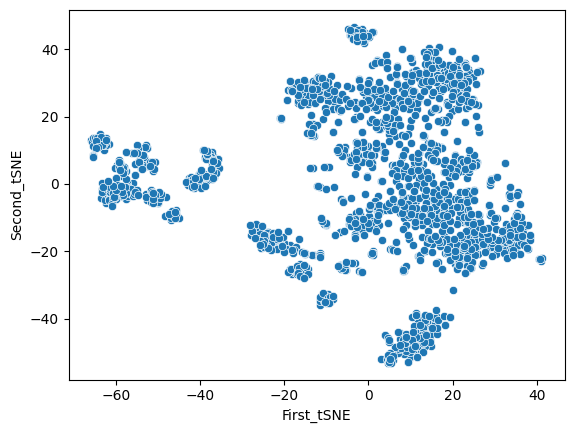

In [38]:
sns.scatterplot(x= "First_tSNE", y= "Second_tSNE", data= MPE_lineages_reduced)
plt.show()

# Figure 4

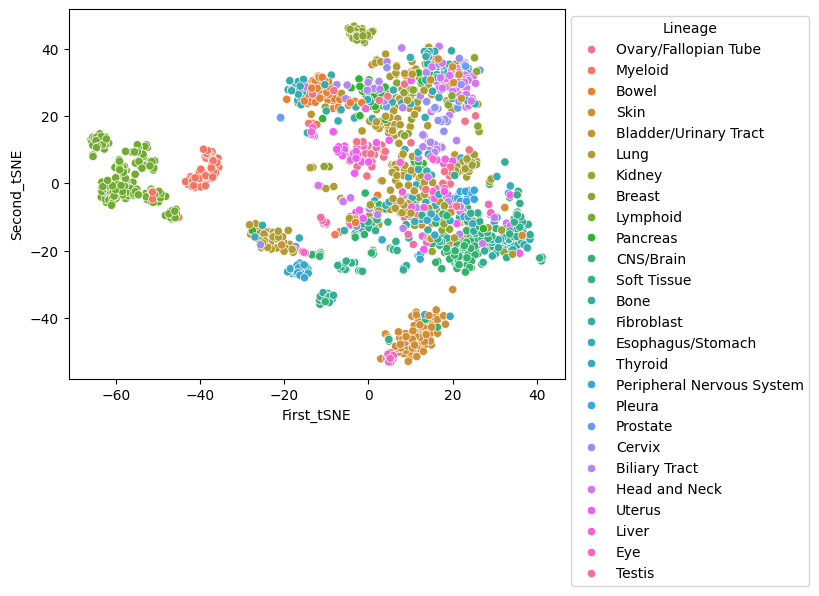

In [39]:
ax = sns.scatterplot(x= "First_tSNE", y= "Second_tSNE", hue= 'Lineage', data= MPE_lineages_reduced)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
#plt.savefig("tSNE_Lineage.pdf", format="pdf", bbox_inches='tight')  

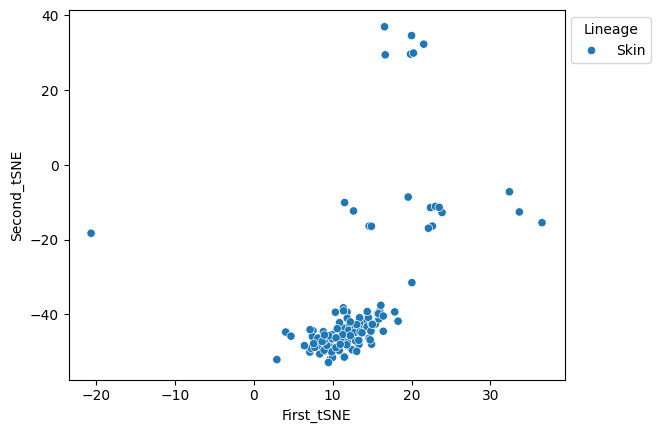

In [47]:
ax = sns.scatterplot(
    x="First_tSNE",
    y="Second_tSNE",
    hue="Lineage",
    data=MPE_lineages_reduced.query("Lineage == 'Skin'")
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

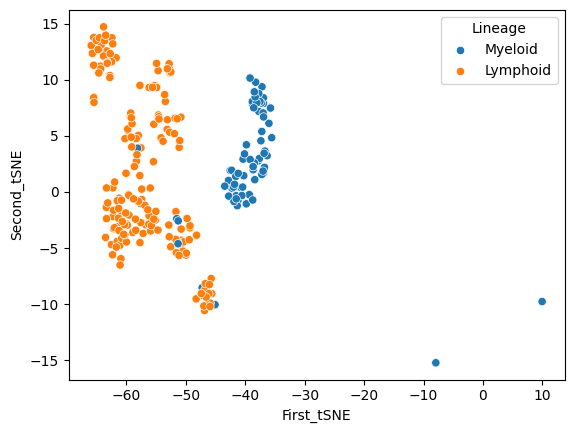

In [45]:
ax = sns.scatterplot(
    x="First_tSNE", y="Second_tSNE", hue="Lineage",
    data=MPE_lineages_reduced.query("Lineage in ['Lymphoid', 'Myeloid']")
)

In [40]:
MPE_lineages_reduced["Lineage"].value_counts()

Lineage
Lung                         222
Lymphoid                     190
Skin                         126
CNS/Brain                    106
Soft Tissue                   88
Bowel                         87
Esophagus/Stomach             86
Myeloid                       79
Head and Neck                 75
Breast                        71
Ovary/Fallopian Tube          67
Bone                          61
Pancreas                      57
Kidney                        53
Biliary Tract                 46
Peripheral Nervous System     46
Uterus                        44
Fibroblast                    42
Bladder/Urinary Tract         38
Liver                         27
Eye                           24
Thyroid                       22
Pleura                        22
Cervix                        22
Prostate                      13
Testis                        10
Name: count, dtype: int64